# 빅데이터분석기사 통계 - PDF 전 범위 완전 강의용 노트북

이 노트북은 업로드한 PDF의 내용을 바탕으로 **시험에 필요한 전 범위**를 한 번에 학습할 수 있도록 만든 강의용 자료입니다.  
단순 요약이 아니라 다음을 모두 포함합니다.

- 아주 쉬운 개념 설명
- 꼭 외워야 하는 공식
- 파이썬 예제 코드
- 그래프와 시뮬레이션
- 시험에서 자주 헷갈리는 포인트
- 계산형 문제 풀이 예시

---

## 구성

1. 모집단, 표본, 모수, 통계량  
2. 표본추출 방법  
3. 표본오차와 비표본오차  
4. 확률의 기초  
5. 조건부확률, 독립, 배반, 베이즈 정리  
6. 확률변수와 확률분포  
7. 기댓값과 분산  
8. 이산확률분포  
9. 연속확률분포  
10. 표본분포와 중심극한정리  
11. 표준오차와 표본비율  
12. 시험 핵심 정리와 연습문제


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

# 재현 가능성을 위해 시드 고정
np.random.seed(42)

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False


## 1. 모집단, 표본, 모수, 통계량

통계를 처음 배울 때 가장 먼저 등장하는 개념이 **모집단, 표본, 모수, 통계량**입니다.  
이 네 개념은 서로 독립된 개념이 아니라 **하나의 흐름으로 연결된 개념**입니다.

통계학은 다음과 같은 질문에서 시작합니다.

- 우리가 알고 싶은 대상은 무엇인가?
- 그 전체를 모두 조사할 수 있는가?
- 전체를 조사할 수 없다면 일부만 조사해서 전체를 어떻게 추정할 것인가?

이 질문에 답하기 위해 등장하는 개념이 바로 **모집단, 표본, 모수, 통계량**입니다.

### 1-1. 모집단과 표본

#### 모집단(population)

모집단은 **우리가 알고 싶은 전체 대상**입니다.  
즉, 관심의 대상이 되는 모든 개체의 집합을 의미합니다.

예를 들어,

- 전국 대학생의 평균 키를 알고 싶다  
  → 모집단은 **전국 대학생 전체**
- 어떤 쇼핑몰 고객의 평균 구매금액을 알고 싶다  
  → 모집단은 **그 쇼핑몰의 전체 고객**
- 어떤 공장에서 생산된 전구의 평균 수명을 알고 싶다  
  → 모집단은 **그 공장에서 생산된 전구 전체**

여기서 중요한 점은 모집단이 꼭 사람일 필요는 없다는 것입니다.

예를 들어 다음도 모집단이 될 수 있습니다.

- 제품 전체
- 거래 기록 전체
- 하루 방문자 데이터 전체
- 센서 데이터 전체

즉 **내가 알고 싶은 전체 집합이 바로 모집단**입니다.

#### 표본(sample)

표본은 모집단 전체 중에서 **실제로 조사한 일부**입니다.

현실에서는 모집단 전체를 조사하기 어렵기 때문에 일부만 뽑아 조사하게 됩니다.  
이렇게 모집단에서 선택된 일부 데이터를 **표본**이라고 합니다.

예를 들어,

- 전국 대학생 1000명을 조사했다  
  → 이 1000명이 표본
- 고객 10만 명 중 2000명을 조사했다  
  → 이 2000명이 표본
- 제품 5만 개 중 100개를 검사했다  
  → 이 100개가 표본

즉,

- 모집단 = 전체
- 표본 = 일부

라고 이해하면 됩니다.

하지만 통계에서는 단순히 "전체와 일부"라는 의미보다 더 중요한 개념이 있습니다.

**표본은 모집단을 대표해야 한다**는 점입니다.

예를 들어 전국 대학생의 평균 키를 알고 싶은데  
운동선수 1000명만 조사했다면 어떻게 될까요?

이 경우 표본은 존재하지만 모집단을 제대로 대표하지 못합니다.  
이렇게 되면 표본 평균으로 모집단 평균을 추정해도 결과가 왜곡됩니다.

따라서 좋은 표본은 단순히 **표본의 수가 많은 것이 아니라 모집단을 잘 대표하는 표본**이어야 합니다.

### 1-2. 모수와 통계량

모집단과 표본을 구분했다면 다음으로 중요한 개념이 **모수(parameter)** 와 **통계량(statistic)** 입니다.

이 두 개념은 통계 문제에서 매우 자주 등장하며 시험에서도 기본적으로 물어보는 개념입니다.

#### 모수(parameter)

모수는 **모집단의 특성을 나타내는 값**입니다.  
즉 우리가 궁극적으로 알고 싶은 값입니다.

대표적인 모수는 다음과 같습니다.

- 모집단 평균: $\mu$
- 모집단 분산: $\sigma^2$
- 모집단 표준편차: $\sigma$
- 모집단 비율: $p$

예를 들어,

- 전국 대학생 전체의 평균 키
- 전체 고객의 평균 구매금액
- 전체 제품의 불량률

이러한 값들은 모집단 전체의 특성을 나타내므로 **모수**라고 합니다.

하지만 현실에서는 대부분의 경우 **모수를 정확히 알 수 없습니다.**

왜냐하면 모수를 정확히 알려면 **모집단 전체를 조사해야 하기 때문**입니다.

그래서 통계에서는 모수를 직접 계산하기보다  
표본을 이용해 **모수를 추정**합니다.

#### 통계량(statistic)

통계량은 **표본에서 계산한 값**입니다.

즉 실제로 우리가 조사한 표본 데이터를 이용해 계산한 값입니다.

대표적인 통계량은 다음과 같습니다.

- 표본평균: $\bar{x}$
- 표본분산: $s^2$
- 표본표준편차: $s$
- 표본비율: $\hat{p}$

예를 들어 전국 대학생 1000명을 조사해서 평균 키가 174.2cm가 나왔다면  
이 값은 **모집단 평균이 아니라 표본평균**입니다.

즉,

- 모집단 평균 → 모수
- 표본 평균 → 통계량

입니다.

통계에서 중요한 점은 다음입니다.

우리가 **진짜 알고 싶은 것은 모수**입니다.  
하지만 실제로 **계산할 수 있는 것은 통계량**입니다.

그래서 통계에서는

**통계량을 이용하여 모수를 추정하는 과정**

이 매우 중요합니다.

예를 들어,

- 표본평균으로 모집단 평균을 추정
- 표본비율로 모집단 비율을 추정
- 표본분산으로 모집단 분산을 추정

이러한 과정을 **통계적 추론**이라고 합니다.

### 1-3. 왜 표본조사를 할까?

처음 통계를 배우는 사람은 이런 질문을 할 수 있습니다.

"전체가 궁금하면 전체를 다 조사하면 되지 않을까?"

이론적으로는 맞습니다.  
전체를 다 조사하면 가장 정확한 결과를 얻을 수 있습니다.

이렇게 모집단 전체를 조사하는 것을 **전수조사**라고 합니다.

하지만 현실에서는 전수조사가 어려운 경우가 많습니다.

#### 이유 1: 시간과 비용 문제

예를 들어 전국 대학생의 평균 키를 조사한다고 가정해봅시다.

전국 대학생 수는 수백만 명입니다.

이 모든 사람을 조사하려면

- 엄청난 조사 인력
- 긴 조사 시간
- 많은 비용

이 필요합니다.

그래서 실제 조사에서는 일부만 조사합니다.

#### 이유 2: 현실적으로 접근이 불가능

모든 사람에게 접근할 수 있는 것도 아닙니다.

예를 들어

- 연락이 닿지 않는 사람
- 해외에 있는 사람
- 참여를 거부하는 사람

이 있을 수 있습니다.

그래서 현실적으로 모집단 전체를 조사하는 것이 불가능한 경우가 많습니다.

#### 이유 3: 파괴검사 문제

어떤 경우는 검사를 하면 대상이 망가집니다.

예를 들어 전구의 수명을 정확히 알려면  
전구가 고장날 때까지 계속 켜야 합니다.

만약 전구 10만 개를 모두 검사하면  
전구 10만 개를 모두 사용해버리게 됩니다.

그래서 일부만 검사해야 합니다.

이런 검사를 **파괴검사**라고 합니다.

#### 이유 4: 빠른 의사결정

현실에서는 빠르게 의사결정을 해야 하는 경우가 많습니다.

예를 들어

- 여론조사
- 고객 만족도 조사
- 제품 품질 검사

같은 경우 전체 데이터를 기다리면 의사결정이 너무 늦어집니다.

그래서 일부 표본만 조사해서 전체를 추정합니다.

### 1-4. 표본조사의 목적

표본조사는 단순히 일부만 보는 것이 아니라  
**전체 모집단의 특성을 추정하기 위한 방법**입니다.

즉,

적은 비용과 시간으로도  
모집단의 특성을 최대한 정확하게 파악하는 것이 목적입니다.

예를 들어

- 표본평균 → 모집단 평균 추정
- 표본비율 → 모집단 비율 추정
- 표본결과 → 정책이나 비즈니스 의사결정

이러한 방식으로 활용됩니다.

### 1-5. 좋은 표본의 조건

좋은 표본이 되기 위해서는 두 가지 조건이 중요합니다.

#### 대표성

표본이 모집단의 특성을 잘 반영해야 합니다.

예를 들어 전국 대학생을 조사하는데  
서울 학생만 조사하면 대표성이 떨어집니다.

#### 편향이 없어야 한다

특정 집단이 과도하게 많이 포함되거나  
반대로 거의 포함되지 않으면 안 됩니다.

예를 들어 온라인 설문만 실시하면  
인터넷 사용이 많은 사람만 응답하게 됩니다.

이 경우 표본이 편향될 수 있습니다.

### 1-6. 쉬운 비유

통계를 이해하는 쉬운 비유가 있습니다.

국이 한 솥 있다고 생각해봅시다.

국 전체의 간이 어떤지 알고 싶습니다.

하지만 국 전체를 다 먹어볼 수는 없습니다.

그래서 국자를 이용해 한 숟가락을 떠서 맛을 봅니다.

여기서

- 국 한 솥 전체 → 모집단
- 국자로 떠낸 한 숟가락 → 표본
- 솥 전체의 실제 간 → 모수
- 한 숟가락의 맛 → 통계량

입니다.

즉,

우리가 알고 싶은 것은 **솥 전체의 간(모수)** 이지만  
실제로 확인할 수 있는 것은 **한 숟가락의 맛(통계량)** 입니다.

그래서 한 숟가락이 솥 전체를 잘 대표해야 합니다.

### 1-7. 시험에서 자주 나오는 포인트

시험에서는 다음과 같은 구분을 묻는 문제가 자주 나옵니다.

- 모집단 → 전체 대상
- 표본 → 일부 대상
- 모수 → 모집단의 특성값
- 통계량 → 표본에서 계산한 값

또한 다음과 같은 함정도 자주 등장합니다.

- 표본평균을 모집단 평균과 혼동
- 통계량을 모수라고 착각
- 표본 수가 많으면 무조건 좋은 표본이라고 생각

하지만 실제로는 **표본을 어떻게 뽑았는지가 더 중요할 수 있습니다.**

### 핵심 정리

이 부분을 가장 간단히 정리하면 다음과 같습니다.

- 모집단은 우리가 알고 싶은 전체 대상이다.
- 표본은 모집단에서 조사한 일부이다.
- 모수는 모집단의 실제 특성값이다.
- 통계량은 표본에서 계산한 값이다.
- 통계는 통계량을 이용해 모수를 추정하는 학문이다.

### 한 줄 요약

통계의 출발점은

**전체를 다 볼 수 없기 때문에 일부를 보고 전체를 추론하는 것**

입니다.

In [3]:
# 모집단과 표본의 차이를 간단히 시뮬레이션
population = np.random.normal(loc=170, scale=6, size=100000)  # 모집단
sample = np.random.choice(population, size=200, replace=False)  # 표본

print("모집단 평균:", round(population.mean(), 2))
print("표본 평균  :", round(sample.mean(), 2))
print("모집단 표준편차:", round(population.std(), 2))
print("표본 표준편차  :", round(sample.std(ddof=1), 2))


모집단 평균: 170.01
표본 평균  : 170.14
모집단 표준편차: 6.01
표본 표준편차  : 5.97


### 해설

표본평균은 모집단평균과 **완전히 같지 않아도 괜찮습니다.**  
중요한 것은 **표본이 모집단을 잘 대표하느냐**입니다.

즉,

- 표본이 잘 뽑혔다면
- 표본평균은 모집단평균 근처에 있을 가능성이 큽니다.


## 2. 표본추출 방법

표본추출(sampling)은 모집단 전체를 조사하지 않고 **일부 데이터를 선택하여 조사하는 과정**입니다.  
앞에서 설명했듯이 통계에서는 표본을 통해 모집단의 특성을 추정하기 때문에 **표본을 어떻게 뽑느냐**가 매우 중요합니다.

표본추출 방법은 크게 두 가지로 나뉩니다.

- **확률표본추출 (Probability Sampling)**  
  → 모든 개체가 선택될 확률이 알려져 있는 방식  
- **비확률표본추출 (Non-Probability Sampling)**  
  → 선택 확률이 명확하지 않은 방식

시험에서는 특히 **확률표본추출 방법의 특징과 차이**를 자주 묻습니다.

## 2-1. 단순무작위추출 (Simple Random Sampling)

단순무작위추출은 가장 기본적인 표본추출 방법입니다.  
모집단에 속한 **모든 개체가 동일한 확률로 선택될 수 있도록** 무작위로 표본을 뽑는 방법입니다.

즉, 어떤 개체가 선택될 확률이 다른 개체와 **완전히 동일해야 합니다.**

예시

- 학생 명단 1,000명 중 컴퓨터로 랜덤하게 100명 선택
- 고객 데이터베이스에서 무작위로 500명 추출

예를 들어 학생 1,000명 중 100명을 뽑는다면  
각 학생이 선택될 확률은 다음과 같습니다.

$P(\text{선택}) = \frac{100}{1000} = 0.1$

모든 학생의 확률이 동일합니다.

장점

- 가장 공정한 추출 방식
- 편향이 적음
- 통계이론 적용이 쉬움

단점

- 모집단 전체 명단이 필요함
- 실제로는 구현이 어려울 수 있음

예를 들어 전국 대학생을 단순무작위추출하려면  
**전국 대학생 명단이 필요합니다.**

## 2-2. 계통추출 (Systematic Sampling)

계통추출은 일정한 **간격(interval)** 을 두고 표본을 선택하는 방법입니다.

예를 들어 모집단이 1,000명이고 표본이 100명이라면  
간격은 다음과 같습니다.

$k = \frac{1000}{100} = 10$

따라서 **10번째마다 한 명씩** 선택합니다.

예시

- 명단에서 10번째마다 1명 선택
- 생산 라인에서 50번째 제품마다 검사

절차

1. 시작 위치를 무작위로 정함  
2. 일정 간격으로 표본을 선택

예를 들어

- 시작 위치 = 3번  
- 간격 = 10  

이면

3, 13, 23, 33, 43 ...

이렇게 선택됩니다.

장점

- 구현이 매우 간단함
- 조사 속도가 빠름

단점

- 모집단에 **주기적인 패턴**이 있으면 문제가 발생할 수 있음

예를 들어 생산 라인에서  
10번째마다 불량이 발생한다면  
계통추출로는 불량이 과대표집될 수 있습니다.

## 2-3. 층화추출 (Stratified Sampling)

층화추출은 모집단을 **비슷한 특성을 가진 여러 그룹(층)** 으로 나눈 뒤  
각 층에서 표본을 추출하는 방법입니다.

여기서 "층(stratum)" 이란  
**특성이 비슷한 집단**을 의미합니다.

예시

- 남학생 / 여학생
- 연령대별 그룹
- 지역별 그룹

예를 들어 학생 1000명 중

- 남학생 600명
- 여학생 400명

이라고 가정합니다.

표본 100명을 추출하려면  
각 층에서 비율대로 추출할 수 있습니다.

남학생

$100 \times \frac{600}{1000} = 60$

여학생

$100 \times \frac{400}{1000} = 40$

따라서

- 남학생 60명
- 여학생 40명

을 선택합니다.

이렇게 하면 모집단의 구조가 표본에도 그대로 반영됩니다.

핵심 특징

층화추출은 **층 내는 동질적**, **층 간은 이질적**일 때 효과적입니다.

즉

- 같은 층 내부는 서로 비슷하고
- 다른 층끼리는 차이가 큽니다.

예를 들어 남학생과 여학생은 키 분포가 다르기 때문에  
층화추출을 사용하면 평균 추정이 더 정확해질 수 있습니다.

장점

- 표본의 대표성이 높아짐
- 추정 정확도 향상

단점

- 층을 나누는 기준을 잘 설정해야 함
- 모집단 정보가 필요함

## 2-4. 군집추출 (Cluster Sampling)

군집추출은 모집단을 여러 **군집(cluster)** 으로 나눈 뒤  
일부 군집을 선택하여 조사하는 방법입니다.

여기서 군집은 보통 **자연적으로 형성된 집단**입니다.

예시

- 학교
- 병원
- 회사
- 지역

예를 들어 전국 학생을 조사한다고 가정합니다.

방법 1

전국 학교 중 20개 학교를 랜덤 선택  
→ 선택된 학교 학생 전부 조사

방법 2

전국 학교 중 20개 학교 선택  
→ 각 학교에서 다시 표본 추출

군집추출은 특히 **대규모 조사에서 비용을 줄이기 위해** 사용됩니다.

장점

- 조사 비용 절감
- 조사 범위 축소

단점

- 표본오차가 커질 수 있음
- 대표성이 떨어질 가능성 있음

## 층화추출 vs 군집추출 (시험 핵심 비교)

층화추출

- 모집단을 여러 층으로 나눔
- 각 층에서 일부씩 표본을 추출

군집추출

- 모집단을 여러 군집으로 나눔
- 일부 군집을 선택하여 조사

핵심 차이

층화추출 → 모든 층을 사용  
군집추출 → 일부 군집만 사용

## 2-5. 비확률표본추출

비확률표본추출은  
각 개체가 선택될 **확률을 정확히 알 수 없는 방법**입니다.

통계적 대표성이 약할 수 있지만  
현실에서는 많이 사용됩니다.

대표적인 방법은 다음과 같습니다.

### 편의추출 (Convenience Sampling)

가장 쉽게 접근할 수 있는 대상만 조사하는 방법입니다.

예

- 길거리 설문
- 온라인 설문
- 강의실 학생만 조사

장점

- 빠르고 저렴함

단점

- 대표성이 낮음

### 판단추출 (Judgment Sampling)

연구자가 **대표성이 있다고 판단하는 대상**을 선택하는 방법입니다.

예

- 전문가 인터뷰
- 특정 고객 그룹 조사

연구자의 판단이 중요하기 때문에  
주관성이 개입될 수 있습니다.

### 할당추출 (Quota Sampling)

모집단의 특정 비율을 맞춰 표본을 선택하는 방법입니다.

예

전체 고객 비율

- 남성 60%
- 여성 40%

표본 100명

- 남성 60명
- 여성 40명

비율은 맞추지만  
선택 자체는 무작위가 아닐 수 있습니다.

### 눈덩이추출 (Snowball Sampling)

처음 조사한 사람이 **다른 사람을 소개**하는 방식입니다.

예

- 특정 직업군 조사
- 희귀 질병 환자 조사

처음 조사 대상이 다른 대상자를 소개하면서  
표본이 점점 늘어납니다.

마치 눈덩이가 커지는 것과 같아서  
눈덩이추출이라고 부릅니다.

## 정리

표본추출 방법을 정리하면 다음과 같습니다.

확률표본추출

- 단순무작위추출
- 계통추출
- 층화추출
- 군집추출

비확률표본추출

- 편의추출
- 판단추출
- 할당추출
- 눈덩이추출

## 시험에서 반드시 기억할 포인트

단순무작위추출  
→ 모든 개체 선택 확률 동일

계통추출  
→ 일정 간격 추출

층화추출  
→ 각 층에서 표본 추출

군집추출  
→ 일부 군집을 선택

편의추출  
→ 조사하기 쉬운 대상

눈덩이추출  
→ 조사 대상이 다음 대상 소개

## 한 줄 요약

표본추출은 **모집단을 대표하는 표본을 어떻게 선택할 것인가**에 대한 방법입니다.

In [4]:
# 층화추출 예시 시뮬레이션
df = pd.DataFrame({
    "gender": np.random.choice(["M", "F"], size=10000, p=[0.55, 0.45]),
    "score": np.random.normal(75, 10, size=10000)
})

simple_sample = df.sample(400, random_state=42)

# 층화추출: gender 비율을 유지
stratified_parts = []
for g, sub in df.groupby("gender"):
    frac = len(sub) / len(df)
    stratified_parts.append(sub.sample(int(400 * frac), random_state=42))
stratified_sample = pd.concat(stratified_parts)

print("전체 성비")
print(df["gender"].value_counts(normalize=True).round(3))
print("\n단순무작위추출 성비")
print(simple_sample["gender"].value_counts(normalize=True).round(3))
print("\n층화추출 성비")
print(stratified_sample["gender"].value_counts(normalize=True).round(3))


전체 성비
gender
M    0.555
F    0.445
Name: proportion, dtype: float64

단순무작위추출 성비
gender
M    0.548
F    0.452
Name: proportion, dtype: float64

층화추출 성비
gender
M    0.556
F    0.444
Name: proportion, dtype: float64


### 시험 포인트

- **층화추출**: 각 집단의 비율을 반영하고 싶을 때
- **군집추출**: 비용 절감이 중요할 때
- **비확률추출**: 대표성보다 편의성이 중요할 때

### 자주 헷갈리는 비교

- 층화추출: 모든 층에서 일부씩 뽑음
- 군집추출: 군집 자체를 몇 개 뽑음


# 3. 표본오차와 비표본오차

모집단 전체를 조사하기 어려워 **표본조사**를 사용하지만, 이때 조사 결과는 실제 모집단 값과 완전히 같지 않을 수 있습니다.  
이러한 차이를 **오차(error)** 라고 합니다.

예를 들어 모집단 평균이 70점인데 표본 평균이 68점이라면  
이 차이는 조사 과정에서 발생한 오차입니다.

통계에서 오차는 크게 두 가지로 구분합니다.

- **표본오차 (Sampling Error)**
- **비표본오차 (Non-Sampling Error)**

두 오차는 **발생 원인이 다릅니다.**



# 3-1. 표본오차

표본오차는 **모집단 전체가 아니라 일부만 조사했기 때문에 발생하는 차이**입니다.

예를 들어 전국 대학생 평균 키가 174cm라고 가정합니다.  
1000명을 표본으로 조사했더니 평균이 173.4cm가 나왔다면  
이 차이가 바로 **표본오차**입니다.

즉 표본오차는

- 표본조사를 하면 **자연스럽게 발생할 수 있는 오차**
- 조사자의 실수가 아니라 **표본이라는 방법 자체에서 발생하는 차이**

입니다.

## 특징

- 표본조사에서는 자연스럽게 발생
- 표본이 달라지면 결과도 조금씩 달라짐
- 표본이 클수록 일반적으로 감소
- 완전히 제거하기는 어려움

## 줄이는 방법

### 1) 표본 크기 증가
표본이 많을수록 모집단을 더 잘 반영할 가능성이 커집니다.

### 2) 확률표본추출 사용
단순무작위추출, 층화추출 등 대표성을 높이는 방식 사용



# 3-2. 비표본오차

비표본오차는 **조사 과정의 문제 때문에 발생하는 오차**입니다.  
이는 **전수조사에서도 발생할 수 있습니다.**

## 예시

### 1) 설문 문항 문제
질문이 모호하여 응답자가 다르게 해석하는 경우

### 2) 응답 오류
거짓 응답, 기억 오류

### 3) 조사자의 실수
기록 오류, 질문 전달 오류

### 4) 데이터 입력 오류
예: 32세 → 23세 입력

### 5) 무응답 문제
특정 집단만 응답하여 결과가 왜곡되는 경우

## 특징

- 조사 설계 및 수행 과정에서 발생
- 전수조사에서도 발생 가능
- 표본 수를 늘려도 자동으로 해결되지 않음
- 경우에 따라 **표본오차보다 더 심각할 수 있음**



# 3-3. 표본오차와 비표본오차 비교

| 구분 | 표본오차 | 비표본오차 |
|---|---|---|
| 발생 원인 | 일부만 조사했기 때문 | 조사 과정의 문제 |
| 전수조사 발생 | 발생하지 않음 | 발생 가능 |
| 표본 수 증가 효과 | 감소함 | 크게 영향 없음 |
| 예 | 표본 평균과 모집단 평균 차이 | 설문 오류, 입력 오류 |



# 3-4. 핵심 정리

- **표본오차** → 일부만 조사했기 때문에 발생하는 자연스러운 차이  
- **비표본오차** → 조사 설계, 응답, 입력 과정에서 발생하는 오류  
- 표본오차는 **표본 크기를 늘리면 줄일 수 있음**  
- 비표본오차는 **조사 설계와 관리 품질 개선이 필요**



# 한 줄 정리

**표본오차는 표본조사 때문에 생기는 차이이고,  
비표본오차는 조사 과정의 오류 때문에 발생한다.**

## 4. 확률의 기초

확률은 통계와 데이터분석의 가장 기본이 되는 개념입니다.  
통계를 배우는 이유가 결국 **불확실한 상황에서 합리적으로 판단하기 위해서**이기 때문에, 확률을 이해하는 것은 매우 중요합니다.

현실의 많은 문제는 확실하게 단정할 수 없습니다.

예를 들어

- 내일 비가 올까?
- 어떤 고객이 상품을 구매할까?
- 대출 신청자가 연체할까?
- 검사 결과가 양성이면 실제로 질병이 있을까?

이런 문제는 "반드시 일어난다" 또는 "절대 일어나지 않는다"처럼 단순하게 말할 수 없습니다.  
대신 **얼마나 가능성이 높은가**를 숫자로 표현해야 합니다.

그때 사용하는 개념이 바로 **확률(probability)** 입니다.

## 4-1. 확률이란?

확률은 어떤 사건이 일어날 가능성을 **0에서 1 사이의 숫자**로 나타낸 것입니다.

즉, 확률은 불확실한 일을 숫자로 표현하는 방법입니다.

확률의 값은 항상 다음 범위 안에 있습니다.

$0 \le P(A) \le 1$

여기서 $P(A)$ 는  
"사건 $A$ 가 발생할 확률"을 의미합니다.

### 확률값의 의미

- $P(A)=0$  
  → 절대 발생하지 않음
- $P(A)=1$  
  → 반드시 발생함
- $P(A)=0.5$  
  → 절반 정도의 가능성
- $P(A)=0.9$  
  → 매우 높은 가능성
- $P(A)=0.1$  
  → 매우 낮은 가능성

예를 들어 공정한 동전을 한 번 던질 때  
앞면이 나올 확률은 $0.5$ 입니다.

공정한 주사위를 한 번 던질 때  
3이 나올 확률은 $1/6$ 입니다.

즉 확률은  
**어떤 일이 일어날 가능성을 수학적으로 표현한 값**입니다.

### 왜 확률이 중요한가?

확률은 단순히 동전이나 주사위 문제를 푸는 데만 쓰이는 개념이 아닙니다.  
실제 데이터분석과 머신러닝에서도 매우 중요합니다.

예를 들어

- 고객이 상품을 구매할 확률
- 대출 고객이 연체할 확률
- 특정 이메일이 스팸일 확률
- 어떤 질병을 가질 확률

이처럼 확률은 현실의 불확실한 문제를 다루는 핵심 도구입니다.

## 4-2. 표본공간과 사건

확률을 제대로 이해하려면 먼저 **표본공간(sample space)** 과 **사건(event)** 이라는 개념을 알아야 합니다.

### 표본공간 $S$

표본공간은  
**어떤 실험에서 나올 수 있는 모든 가능한 결과의 집합**입니다.

쉽게 말해  
"가능한 결과를 전부 모아놓은 집합"입니다.

예를 들어 주사위 1개를 던지면 나올 수 있는 값은 다음과 같습니다.

$S = \{1,2,3,4,5,6\}$

이것이 바로 표본공간입니다.

다른 예를 보면

동전을 한 번 던질 때의 표본공간은

$S = \{\text{앞면}, \text{뒷면}\}$

동전을 두 번 던질 때의 표본공간은

$S = \{(\text{앞,앞}), (\text{앞,뒤}), (\text{뒤,앞}), (\text{뒤,뒤})\}$

이처럼 표본공간은  
실험 결과로 가능한 모든 경우를 포함합니다.

### 사건 $A$

사건은  
표본공간 안에서 **우리가 관심을 가지는 결과들의 집합**입니다.

즉, 표본공간 전체 중에서  
특정 조건에 해당하는 결과만 모은 것이 사건입니다.

예를 들어 주사위를 한 번 던질 때  
짝수가 나오는 사건을 생각해보면

$A = \{2,4,6\}$

입니다.

여기서

- 표본공간은 전체 가능한 결과
- 사건은 그중 우리가 관심 있는 일부 결과

입니다.

다른 예를 보면

주사위 1개를 던질 때 4 이상이 나오는 사건은

$A = \{4,5,6\}$

입니다.

동전을 두 번 던질 때 앞면이 한 번 이상 나오는 사건은

$A = \{(\text{앞,앞}), (\text{앞,뒤}), (\text{뒤,앞})\}$

입니다.

즉 사건은  
**표본공간의 부분집합**이라고 이해하면 됩니다.

### 사건의 확률 계산

확률은 보통 다음처럼 계산합니다.

$P(A) = \frac{\text{사건 A에 해당하는 경우의 수}}{\text{전체 가능한 경우의 수}}$

예를 들어 주사위를 한 번 던질 때  
짝수 사건 $A = \{2,4,6\}$ 의 확률은

- 전체 경우의 수: 6
- 짝수에 해당하는 경우의 수: 3

따라서

$P(A) = \frac{3}{6} = 0.5$

입니다.

즉, 짝수가 나올 확률은 0.5입니다.

### 쉬운 해석

확률은 결국  
"전체 경우 중 내가 원하는 경우가 얼마나 차지하는가"  
를 나타냅니다.

즉,

- 전체 결과를 먼저 파악하고
- 관심 있는 결과를 골라낸 뒤
- 그 비율을 계산하는 것

이 확률의 기본 아이디어입니다.

## 4-3. 확률의 기본 성질

확률은 아무 숫자나 될 수 있는 것이 아닙니다.  
반드시 따라야 하는 기본 규칙이 있습니다.

이 규칙을 알아야 나중에 조건부확률, 베이즈 정리, 확률분포까지 이해할 수 있습니다.

### 1) 확률은 0과 1 사이의 값이다

$0 \le P(A) \le 1$

이 식은 확률의 가장 기본적인 성질입니다.

확률은 가능성을 나타내는 값이기 때문에

- 0보다 작을 수 없고
- 1보다 클 수도 없습니다.

예를 들어 확률이 1.3이라면 말이 안 됩니다.  
가능성이 100%를 넘을 수는 없기 때문입니다.

마찬가지로 확률이 -0.2라는 것도 말이 안 됩니다.  
가능성이 음수일 수는 없기 때문입니다.

즉 확률은 항상 0 이상 1 이하입니다.

### 2) 표본공간 전체의 확률은 1이다

$P(S)=1$

표본공간은 가능한 모든 결과를 모아놓은 집합입니다.  
실험을 하면 그 결과는 반드시 표본공간 안에 있는 어떤 값 하나로 나타납니다.

예를 들어 주사위를 던지면  
1, 2, 3, 4, 5, 6 중 하나는 반드시 나옵니다.

따라서 전체 가능한 결과의 집합인 표본공간의 확률은 항상 1입니다.

즉,

"무언가 하나는 반드시 일어난다"

는 뜻입니다.

### 3) 여사건의 확률

$P(A^c)=1-P(A)$

여기서 $A^c$ 는  
사건 $A$ 가 **일어나지 않는 사건**, 즉 **여사건(complement)** 입니다.

예를 들어 주사위를 던질 때  
짝수가 나오는 사건을 $A = \{2,4,6\}$ 라고 하면

짝수가 **아닌** 사건은

$A^c = \{1,3,5\}$

입니다.

짝수가 나올 확률이

$P(A)=0.5$

라면

짝수가 아닐 확률은

$P(A^c)=1-0.5=0.5$

입니다.

이 공식은 매우 자주 사용됩니다.

왜냐하면 어떤 사건을 직접 계산하기보다  
그 반대 사건을 계산하는 것이 더 쉬운 경우가 많기 때문입니다.

예를 들어

"적어도 한 번 성공할 확률"은 계산이 복잡할 수 있지만  
"한 번도 성공하지 않을 확률"을 먼저 구한 뒤  
1에서 빼면 쉽게 구할 수 있습니다.

### 4) 합집합 확률

$P(A \cup B)=P(A)+P(B)-P(A \cap B)$

이 식은  
사건 $A$ 또는 사건 $B$ 가 일어날 확률을 의미합니다.

여기서

- $A \cup B$ 는 "A 또는 B"
- $A \cap B$ 는 "A 이고 B"

를 뜻합니다.

### 왜 $P(A)+P(B)$ 만 하면 안 될까?

많은 초보자가  
"A 또는 B" 의 확률을 구할 때 그냥

$P(A)+P(B)$

를 떠올리지만, 이렇게 하면 **겹치는 부분을 두 번 더하게 됩니다.**

예를 들어

- $P(A)=0.6$
- $P(B)=0.5$
- $P(A \cap B)=0.2$

라면

그냥 더하면

$0.6 + 0.5 = 1.1$

이 됩니다.

하지만 확률은 1을 넘을 수 없으므로 잘못된 계산입니다.

왜 이런 일이 생길까요?

$A$ 와 $B$ 를 더할 때  
$A$ 와 $B$ 에 동시에 속한 부분을 두 번 더했기 때문입니다.

그래서 그 겹치는 부분인 $P(A \cap B)$ 를 한 번 빼줘야 합니다.

즉

$P(A \cup B)=P(A)+P(B)-P(A \cap B)$

가 됩니다.

### 예시

주사위를 한 번 던질 때

- $A$ = 짝수가 나오는 사건 = $\{2,4,6\}$
- $B$ = 4 이상이 나오는 사건 = $\{4,5,6\}$

그러면

- $P(A)=3/6$
- $P(B)=3/6$
- $A \cap B = \{4,6\}$ 이므로 $P(A \cap B)=2/6$

따라서

$P(A \cup B)=\frac{3}{6}+\frac{3}{6}-\frac{2}{6}=\frac{4}{6}$

즉,

$A \cup B = \{2,4,5,6\}$

이므로 확률은 $4/6$ 입니다.

### 직관적으로 이해하기

합집합은  
"두 사건 중 적어도 하나가 일어나는 경우"입니다.

즉

- A만 일어나도 포함
- B만 일어나도 포함
- 둘 다 일어나도 포함

입니다.

그래서 전체를 더하되 겹친 부분은 한 번 빼는 것입니다.

## 4-4. 확률의 기본 개념이 왜 중요한가

지금 배우는 내용은 단순한 기초처럼 보이지만  
뒤에서 배우게 될 모든 확률이론의 출발점입니다.

예를 들어

- 조건부확률
- 독립사건
- 베이즈 정리
- 확률분포
- 통계적 추론

이 모든 내용은 지금 배우는 표본공간, 사건, 합집합, 여사건 개념 위에 세워집니다.

즉, 확률의 기초를 정확히 이해해야  
뒤의 내용을 쉽게 이해할 수 있습니다.

## 4-5. 시험에서 자주 나오는 포인트

시험에서는 다음 개념을 자주 묻습니다.

- 표본공간의 정의
- 사건의 정의
- 여사건의 확률
- 합집합 확률 계산
- 확률의 범위

예를 들어

- "사건이 일어나지 않을 확률은?"  
  → 여사건 $P(A^c)=1-P(A)$
- "A 또는 B가 일어날 확률은?"  
  → $P(A \cup B)=P(A)+P(B)-P(A \cap B)$
- "확률값이 될 수 없는 것은?"  
  → 0보다 작거나 1보다 큰 값

### 자주 하는 실수

- 사건을 하나의 값으로만 생각하는 것  
  → 사건은 **결과들의 집합**입니다.
- 합집합 확률에서 교집합을 빼지 않는 것
- 여사건 개념을 반대로 이해하는 것

## 4-6. 핵심 정리

- 확률은 사건이 일어날 가능성을 0에서 1 사이의 숫자로 나타낸 것이다.
- 표본공간은 가능한 모든 결과의 집합이다.
- 사건은 표본공간 중 우리가 관심 있는 결과들의 집합이다.
- 여사건의 확률은 $1-P(A)$ 이다.
- 합집합 확률은 겹치는 부분을 빼서 계산해야 한다.

## 4-7. 한 줄 요약

확률의 기초는  
**가능한 모든 결과 중에서 내가 관심 있는 결과가 얼마나 되는지를 수학적으로 표현하는 방법**입니다.

In [5]:
# 주사위 실험으로 확률 확인
dice = np.random.randint(1, 7, size=100000)
p_even = np.mean(np.isin(dice, [2, 4, 6]))
p_ge4 = np.mean(dice >= 4)

print("짝수 확률(시뮬레이션):", round(p_even, 4))
print("4 이상 확률(시뮬레이션):", round(p_ge4, 4))


짝수 확률(시뮬레이션): 0.4978
4 이상 확률(시뮬레이션): 0.4996


### 왜 합집합에서 교집합을 빼야 할까?

$P(A)+P(B)$를 그냥 더하면  
A와 B에 동시에 속한 부분을 **두 번 더하게 됩니다.**

그래서

$$
P(A \cup B)=P(A)+P(B)-P(A \cap B)
$$

입니다.


## 5. 조건부확률, 독립, 배반, 베이즈 정리

확률 이론에서 매우 중요한 개념이 바로 **조건부확률, 독립사건, 배반사건, 베이즈 정리**입니다.  
이 개념들은 서로 연결되어 있으며, 실제 데이터 분석과 머신러닝에서도 매우 자주 사용됩니다.

예를 들어 다음과 같은 상황을 생각해 볼 수 있습니다.

- 고객이 특정 상품을 구매할 확률
- 특정 질병 검사에서 양성이 나왔을 때 실제로 질병이 있을 확률
- 어떤 이메일이 스팸일 확률
- 대출 신청자가 연체할 확률

이러한 문제들은 단순 확률이 아니라 **조건이 붙은 확률**을 계산해야 합니다.  
그래서 조건부확률 개념이 중요합니다.

또한 두 사건이 서로 영향을 주는지 아닌지를 판단하는 **독립사건** 개념도 중요합니다.

마지막으로 조건부확률을 이용해 원인을 추론하는 **베이즈 정리**는 데이터 분석에서 매우 중요한 도구입니다.

## 5-1. 조건부확률

조건부확률은 **어떤 사건이 이미 발생했다는 조건 아래에서 다른 사건이 발생할 확률**입니다.

즉, 전체 상황이 아니라 **조건이 바뀐 새로운 상황에서 확률을 계산하는 것**입니다.

조건부확률은 다음과 같이 표현합니다.

$P(A|B)$

이 표현은 다음과 같은 의미입니다.

"사건 $B$ 가 이미 발생했다는 조건에서 사건 $A$ 가 발생할 확률"

조건부확률의 공식은 다음과 같습니다.

$P(A|B)=\frac{P(A \cap B)}{P(B)}$

여기서

- $P(A \cap B)$ 는 사건 $A$ 와 $B$ 가 동시에 발생할 확률
- $P(B)$ 는 사건 $B$ 가 발생할 확률

입니다.

### 왜 분모가 바뀔까?

조건부확률의 핵심은 **기준이 바뀐다는 것**입니다.

일반 확률에서는 전체 표본공간이 기준입니다.

하지만 조건부확률에서는 **조건이 되는 사건이 새로운 표본공간이 됩니다.**

즉

전체 기준 → $S$  
조건부 기준 → $B$

그래서 분모가 $P(B)$ 로 바뀝니다.

### 예시

어떤 학교 학생 100명 중

- 여학생 40명
- 남학생 60명

이라고 가정합니다.

또한 합격자는 다음과 같습니다.

- 여학생 합격자 20명
- 남학생 합격자 30명

이때 전체 합격 확률은

$P(\text{합격})=\frac{50}{100}=0.5$

입니다.

하지만 **여학생이라는 조건에서 합격 확률**을 계산하면

$P(\text{합격}|\text{여학생})=\frac{20}{40}=0.5$

입니다.

여기서 중요한 점은

전체 기준이 아니라 **여학생 그룹만을 기준으로 확률을 계산했다는 것**입니다.

즉 조건부확률에서는 **분모가 바뀌게 됩니다.**

### 조건부확률의 직관적인 이해

조건부확률은 다음과 같이 생각하면 쉽습니다.

"전체가 아니라 특정 그룹 안에서 다시 확률을 계산하는 것"

예를 들어

- 전체 학생 중 합격 확률
- 여학생 중 합격 확률
- 컴퓨터공학과 학생 중 합격 확률

이처럼 조건이 붙으면 **확률을 계산하는 기준 집단이 달라집니다.**



## 5-2. 독립사건

두 사건이 서로 영향을 주지 않을 때 **독립(independent)** 이라고 합니다.

즉

- 사건 $A$ 가 발생한다고 해서
- 사건 $B$ 의 확률이 바뀌지 않는 경우입니다.

독립사건의 수학적 조건은 다음과 같습니다.

$P(A \cap B)=P(A)P(B∣A)$

$P(A \cap B)=P(A)P(B)$

즉 두 사건이 동시에 발생할 확률이  
각 사건의 확률을 곱한 값과 같으면 독립입니다.  
`교집합` 확률은: `첫 사건이 발생하고, 그 다음 사건이 발생할 확률`

### 독립사건의 예

동전을 두 번 던지는 경우를 생각해봅시다.

첫 번째 동전이 앞면이 나올 확률

$P(A)=0.5$

두 번째 동전이 앞면이 나올 확률

$P(B)=0.5$

두 사건이 동시에 발생할 확률은

$P(A \cap B)=0.5 \times 0.5 = 0.25$

첫 번째 동전 결과는 두 번째 동전에 영향을 주지 않습니다.

그래서 두 사건은 독립입니다.

### 독립사건의 특징

독립사건에서는 다음 관계가 성립합니다.

$P(A|B)=P(A)$

즉 사건 $B$ 가 일어나도  
사건 $A$ 의 확률이 변하지 않습니다.

이것이 바로 **서로 영향을 주지 않는다는 의미**입니다.

### 독립사건의 예

- 동전을 두 번 던지기
- 서로 다른 주사위 던지기
- 서로 다른 날의 날씨 (단순 모델)

하지만 현실에서는 완전히 독립인 경우가 생각보다 많지 않습니다.

예를 들어

- 소득과 소비
- 나이와 질병
- 학습시간과 시험점수

이런 변수들은 서로 영향을 줄 가능성이 높습니다.



## 5-3. 배반사건

배반사건은 **두 사건이 동시에 발생할 수 없는 경우**입니다.

즉 두 사건이 서로 **겹칠 수 없는 경우**입니다.

수학적으로는 다음과 같이 표현됩니다.

$P(A \cap B)=0$

즉 두 사건의 교집합이 존재하지 않습니다.

### 배반사건의 예

주사위를 한 번 던질 때

사건 $A$ = 1이 나오는 사건

$A=\{1\}$

사건 $B$ = 2가 나오는 사건

$B=\{2\}$

이 두 사건은 동시에 일어날 수 없습니다.

그래서

$P(A \cap B)=0$

입니다.

### 또 다른 예

동전을 한 번 던질 때

사건 $A$ = 앞면

사건 $B$ = 뒷면

이 두 사건은 동시에 일어날 수 없습니다.

그래서 배반사건입니다.

### 배반사건의 확률 공식

배반사건에서는 다음 공식이 성립합니다.

$P(A \cup B)=P(A)+P(B)$

왜냐하면 두 사건이 겹치는 부분이 없기 때문입니다.

일반적으로는

$P(A \cup B)=P(A)+P(B)-P(A \cap B)$

인데

배반사건에서는

$P(A \cap B)=0$

이므로

$P(A \cup B)=P(A)+P(B)$

가 됩니다.

## 아주 중요한 비교: 독립 vs 배반

많은 학생들이 **독립과 배반을 혼동**합니다.

하지만 이 둘은 완전히 다른 개념입니다.

독립사건

- 서로 영향을 주지 않음
- 동시에 발생할 수 있음

예

- 동전 두 번 던지기

배반사건

- 동시에 발생할 수 없음
- 교집합이 없음

예

- 주사위에서 1과 2

### 중요한 사실

대부분의 경우 **배반사건은 독립이 아닙니다.**

예를 들어

주사위를 던질 때

사건 $A$ = 1이 나오는 사건

사건 $B$ = 2가 나오는 사건

이 두 사건은 배반입니다.

하지만 독립은 아닙니다.

왜냐하면

$P(A)=\frac{1}{6}$  
$P(B)=\frac{1}{6}$

라면

$P(A)P(B)=\frac{1}{36}$

이어야 독립인데

실제로는

$P(A \cap B)=0$

입니다.

따라서 독립이 아닙니다.

즉

**배반 ≠ 독립**

입니다.


---

## 5-4. 베이즈 정리

베이즈 정리는 **어떤 결과가 관측되었을 때 그 결과의 원인이 될 사건의 확률을 다시 계산하는 방법**입니다.  
즉 **결과 → 원인** 방향의 확률을 계산하는 공식입니다.

일반적인 확률 계산은 다음과 같습니다.

- 원인 → 결과  
  예: 질병이 있으면 검사 양성

하지만 실제 질문은 보통 다음과 같습니다.

- 결과 → 원인  
  예: 검사 결과가 양성이면 실제로 질병일 확률은?

이때 사용하는 것이 **베이즈 정리**입니다.



### 1) 베이즈 정리 공식

$$
P(A|B)=\frac{P(B|A)P(A)}{P(B)}
$$

각 항의 의미

- **$P(A)$** : 사전확률 (원인이 발생할 기본 확률)  
- **$P(B|A)$** : 가능도 (원인이 있을 때 결과가 발생할 확률)  
- **$P(B)$** : 결과가 발생할 전체 확률  
- **$P(A|B)$** : 사후확률 (결과를 보고 원인이 맞을 확률)



### 2) 전체 결과 확률 계산

베이즈 정리를 사용하려면 먼저 **결과의 전체 확률**을 계산해야 합니다.

어떤 결과 \(B\) 는 보통 두 가지 경우에서 발생합니다.

- A가 원인일 때 발생
- A가 아닌 경우에서 발생

따라서

$$
P(B)=P(B|A)P(A)+P(B|A^c)P(A^c)
$$

이를 **전체확률의 법칙**이라고 합니다.



### 3) 예시: 질병 검사 문제

어떤 질병의 발생률이 **1%**라고 가정합니다.

$$
P(\text{질병})=0.01
$$

검사의 특성

질병이 있을 때 양성

$$
P(\text{양성}|\text{질병})=0.95
$$

정상일 때 양성

$$
P(\text{양성}|\text{정상})=0.05
$$

우리가 구하려는 값

$$
P(\text{질병}|\text{양성})
$$



### 4) 전체 양성 확률 계산

양성이 나오는 경우

1. 실제 질병인데 양성  
2. 정상인데 양성

정상 확률

$$
P(\text{정상})=1-0.01=0.99
$$

따라서

$$
P(\text{양성})
=
0.95 \times 0.01
+
0.05 \times 0.99
$$

$$
=0.0095+0.0495
=0.059
$$



### 5) 베이즈 정리 적용

$$
P(\text{질병}|\text{양성})
=
\frac{P(\text{양성}|\text{질병})P(\text{질병})}{P(\text{양성})}
$$

값을 대입하면

$$
P(\text{질병}|\text{양성})
=
\frac{0.95 \times 0.01}{0.059}
=
\frac{0.0095}{0.059}
\approx 0.161
$$



### 6) 최종 결과

$$
P(\text{질병}|\text{양성}) \approx 0.161
$$

즉

**양성이 나왔을 때 실제로 질병일 확률은 약 16.1%입니다.**



### 7) 직관적 이해 (10,000명 기준)

| 구분 | 인원 |
|---|---|
| 질병 환자 | 100 |
| 정상 | 9,900 |

검사 결과

| 구분 | 양성 |
|---|---|
| 질병 환자 | 95 |
| 정상 | 495 |

전체 양성

$$
95+495=590
$$

양성 중 실제 질병 비율

$$
\frac{95}{590}\approx0.161
$$



### 8) 핵심 정리

베이즈 정리는 **결과를 보고 원인의 확률을 업데이트하는 방법**입니다.

계산 과정

1️⃣ 전체 결과 확률 계산  

$$
P(B)=P(B|A)P(A)+P(B|A^c)P(A^c)
$$

2️⃣ 베이즈 공식 적용  

$$
P(A|B)=\frac{P(B|A)P(A)}{P(B)}
$$



### 한 줄 요약

베이즈 정리는  

**결과가 관측되었을 때 그 결과의 원인이 될 사건의 확률을 다시 계산하는 공식입니다.**

---

## 6. 확률변수와 확률분포

확률이론에서 중요한 단계는 **사건을 숫자로 표현하는 것**입니다.  
앞에서는 사건과 확률을 배웠지만, 실제 데이터 분석에서는 결과를 **숫자 형태의 변수**로 표현해야 계산과 분석이 가능합니다.

예를 들어 동전을 던졌을 때

- 앞면
- 뒷면

이라는 결과만 가지고는 수학적 계산이 어렵습니다.

그래서 다음처럼 숫자로 바꿉니다.

- 앞면 = 1
- 뒷면 = 0

이렇게 **확률 실험의 결과를 숫자로 표현한 것**을 **확률변수(random variable)** 라고 합니다.

확률변수는 통계와 머신러닝에서 매우 중요한 개념입니다.  
왜냐하면 실제 데이터 분석에서는 대부분 **확률변수를 이용해 데이터를 모델링**하기 때문입니다.

예를 들어

- 하루 방문 고객 수
- 고객의 구매 금액
- 대출 연체 여부
- 제품 불량 개수

이런 값들은 모두 확률변수로 볼 수 있습니다.



## 6-1. 확률변수란?

확률변수는 **확률 실험의 결과를 숫자로 나타낸 변수**입니다.

즉, 어떤 실험을 했을 때 나올 수 있는 결과를 **숫자로 표현한 것**입니다.

확률변수는 보통 다음과 같이 기호로 표현합니다.

$X$

즉

- 확률변수 → $X$
- 그 값 → $x$

### 예시 1: 동전 던지기

동전을 한 번 던지는 실험을 생각해봅시다.

표본공간

$S = \{\text{앞면}, \text{뒷면}\}$

이를 확률변수로 표현하면

- 앞면 → 1
- 뒷면 → 0

즉 확률변수 $X$ 는 다음 값을 가질 수 있습니다.

$X = \{0,1\}$

### 예시 2: 동전 3번 던지기

동전을 3번 던질 때 앞면 개수를 확률변수로 정의할 수 있습니다.

가능한 값

$X = \{0,1,2,3\}$

즉

- 앞면 0개
- 앞면 1개
- 앞면 2개
- 앞면 3개

가 될 수 있습니다.

### 예시 3: 실제 데이터

확률변수는 실제 데이터에서도 많이 사용됩니다.

예

- 하루 방문 고객 수
- 하루 판매량
- 하루 불량 제품 수
- 고객의 구매 횟수

이처럼 **개수를 세거나 측정할 수 있는 값**은 확률변수가 됩니다.



## 6-2. 이산확률변수와 연속확률변수

확률변수는 크게 두 가지 종류로 나뉩니다.

- 이산확률변수 (Discrete Random Variable)
- 연속확률변수 (Continuous Random Variable)

이 구분은 **가능한 값의 형태**에 따라 나뉩니다.

### 이산확률변수

이산확률변수는 **값을 하나하나 셀 수 있는 경우**입니다.

즉 가능한 값이 **개별적인 숫자들**로 이루어져 있습니다.

예

- 주사위 눈 → 1,2,3,4,5,6
- 동전 앞면 개수 → 0,1,2,3
- 고객 수 → 0,1,2,3,...
- 불량 제품 개수 → 0,1,2,...

이산확률변수의 특징

- 값이 **정수 형태**
- 값을 **하나씩 셀 수 있음**

예를 들어 하루 방문 고객 수는

0명, 1명, 2명, 3명 ...

처럼 셀 수 있기 때문에 이산확률변수입니다.

### 연속확률변수

연속확률변수는 **일정 구간 안의 모든 값을 가질 수 있는 변수**입니다.

즉 값이 **연속적인 범위**를 가집니다.

예

- 키
- 몸무게
- 시간
- 수명
- 대기시간
- 온도

예를 들어 사람의 키는

170cm, 170.1cm, 170.15cm, 170.153cm ...

처럼 무한히 많은 값을 가질 수 있습니다.

따라서 연속확률변수입니다.

### 이산 vs 연속 비교

이산확률변수

- 값을 셀 수 있음
- 보통 정수
- 개수 데이터

예

- 고객 수
- 불량 개수
- 동전 앞면 개수

연속확률변수

- 값을 셀 수 없음
- 구간 전체 값을 가짐
- 측정 데이터

예

- 키
- 몸무게
- 시간
- 온도

### 쉬운 구분 방법

다음 질문을 해보면 쉽게 구분할 수 있습니다.

"이 값을 하나씩 셀 수 있는가?"

- 가능 → 이산확률변수
- 불가능 → 연속확률변수


## 6-3. 확률분포

확률변수는 하나의 값만 가지는 것이 아니라 **여러 가능한 값을 가질 수 있습니다.**  
따라서 확률변수가 어떤 값을 가질 수 있는지뿐만 아니라 **각 값이 얼마나 자주 발생하는지도 함께 알아야 합니다.**

이처럼 **확률변수가 가질 수 있는 값과 그 값이 발생할 확률을 정리한 것**을  
**확률분포(probability distribution)** 라고 합니다.

즉 확률분포는 다음 두 가지 정보를 함께 보여줍니다.

- 확률변수가 가질 수 있는 값
- 각 값이 발생할 확률

다시 말해 확률분포는 **확률변수의 값과 확률의 관계를 체계적으로 정리한 것**입니다.

### 예시: 동전을 두 번 던지는 경우

동전을 두 번 던질 때 가능한 결과는 다음과 같습니다.

| 결과 | 앞면 개수 |
|---|---|
| 앞앞 (HH) | 2 |
| 앞뒤 (HT) | 1 |
| 뒤앞 (TH) | 1 |
| 뒤뒤 (TT) | 0 |

여기서 확률변수 $X$ 를 **앞면의 개수**라고 정의하면  
확률변수가 가질 수 있는 값은 다음과 같습니다.

$$
X = \{0,1,2\}
$$

각 값이 발생하는 확률을 계산해보면

앞면이 0개인 경우

- TT 한 가지

$$
P(X=0)=\frac{1}{4}
$$

앞면이 1개인 경우

- HT
- TH

두 가지 경우가 있으므로

$$
P(X=1)=\frac{2}{4}=\frac{1}{2}
$$

앞면이 2개인 경우

- HH 한 가지

$$
P(X=2)=\frac{1}{4}
$$

따라서 확률분포는 다음과 같이 정리됩니다.

| X | 확률 |
|---|---|
|0|1/4|
|1|1/2|
|2|1/4|

이처럼 **확률변수의 가능한 값과 그 확률을 정리한 것**이 바로 확률분포입니다.

또한 확률분포에서는 모든 확률의 합이 반드시 1이 됩니다.

$$
\frac{1}{4}+\frac{1}{2}+\frac{1}{4}=1
$$

### 정리

확률분포는

- 확률변수가 가질 수 있는 값
- 각 값이 발생할 확률

을 함께 정리한 것이며, **확률변수의 전체적인 발생 패턴을 설명하는 개념**입니다.


### 확률질량함수 (PMF)

이산확률변수의 확률분포를 나타내는 함수는  
**확률질량함수 (Probability Mass Function)** 라고 합니다.

기호

$P(X=x)$

의미

확률변수 $X$ 가 값 $x$ 를 가질 확률

예

주사위

$P(X=1)=\frac{1}{6}$  
$P(X=2)=\frac{1}{6}$  
$P(X=3)=\frac{1}{6}$

이처럼 각 값의 확률을 직접 계산할 수 있습니다.

PMF의 특징

- 모든 확률의 합은 1

즉

$\sum P(X=x)=1$

입니다.



### 확률밀도함수 (PDF)

연속확률변수에서는 특정 값의 확률을 직접 계산할 수 없습니다.

예를 들어 키가 정확히 170cm일 확률은 사실상 0입니다.  
왜냐하면 키는 연속적인 값이기 때문입니다.

그래서 연속확률변수에서는 **구간의 확률**을 계산합니다.

이때 사용하는 함수가 **확률밀도함수 (Probability Density Function)** 입니다.

기호

$f(x)$

구간 확률

$P(a \le X \le b)=\int_a^b f(x)dx$

즉 확률은 **면적**으로 계산됩니다.

### 누적분포함수 (CDF)

누적분포함수는

"특정 값 이하일 확률"

을 나타내는 함수입니다.

기호

$F(x)$

정의

$F(x)=P(X \le x)$

즉 확률변수가 **x 이하의 값을 가질 확률**입니다.

예를 들어 시험 점수 확률변수 $X$ 가 있을 때

$F(70)$

은

"점수가 70점 이하일 확률"

을 의미합니다.

### CDF의 특징

누적분포함수는 다음 성질을 가집니다.

$0 \le F(x) \le 1$

또한

$\lim_{x \to -\infty}F(x)=0$

$\lim_{x \to \infty}F(x)=1$

즉 값이 커질수록 누적확률은 1에 가까워집니다.

### PMF, PDF, CDF 관계

이산확률변수

- PMF 사용
- 각 값의 확률 존재

연속확률변수

- PDF 사용
- 구간 확률 계산

누적분포

- CDF 사용
- 특정 값 이하 확률

### 직관적으로 이해하기

확률분포는 쉽게 말하면

"값이 어떻게 퍼져 있는지 보여주는 규칙"

입니다.

예를 들어

- 고객 방문 수
- 시험 점수
- 제품 수명

같은 데이터가 어떤 패턴으로 나타나는지를 설명합니다.

이 확률분포 개념은 이후에 배우는

- 정규분포
- 포아송분포
- 이항분포
- 지수분포

같은 **확률모형의 기초**가 됩니다.

## 핵심 정리

- 확률변수는 확률실험 결과를 숫자로 표현한 변수이다.
- 확률변수는 이산형과 연속형으로 나뉜다.
- 이산확률변수는 값을 셀 수 있다.
- 연속확률변수는 구간의 값을 가진다.
- 확률분포는 확률변수가 각 값을 가질 가능성을 나타낸다.
- 이산형은 PMF, 연속형은 PDF를 사용한다.
- 누적확률은 CDF로 표현한다.

## 한 줄 요약

확률변수는 **확률실험 결과를 숫자로 표현한 것이고**,  
확률분포는 **그 숫자들이 어떤 확률로 나타나는지 설명하는 규칙**입니다.

---

## 7. 기댓값과 분산

확률변수와 확률분포를 배웠다면, 이제는 그 확률변수가 **어느 위치를 중심으로 분포하는지**, 그리고 **얼마나 넓게 퍼져 있는지**를 숫자로 요약할 수 있어야 합니다.

이때 가장 중요한 개념이 바로 **기댓값(expected value)** 과 **분산(variance)** 입니다.  
그리고 분산을 더 해석하기 쉽게 바꾼 값이 **표준편차(standard deviation)** 입니다.

쉽게 말하면

- 기댓값 → 중심이 어디인가
- 분산 → 얼마나 퍼져 있는가
- 표준편차 → 퍼짐을 원래 단위로 얼마나 쉽게 해석할 수 있는가

를 나타냅니다.

이 세 개념은 통계와 데이터분석에서 정말 자주 사용됩니다.  
평균, 분산, 표준편차는 거의 모든 분석의 기본 요약값이라고 볼 수 있습니다.

## 7-1. 기댓값

기댓값은 확률변수의 **평균적인 중심**입니다.  
확률적으로 보았을 때 결과가 어느 값 주변에 위치하는지를 나타냅니다.

보통 기댓값은 다음 기호로 표시합니다.

$E(X)$

즉 확률변수 $X$ 의 기댓값입니다.

### 이산확률변수의 기댓값

이산형에서는 다음 공식으로 계산합니다.

$E(X)=\sum xP(X=x)$

이 식의 의미는 다음과 같습니다.

- 가능한 값 $x$ 하나하나에
- 그 값이 나올 확률 $P(X=x)$ 를 곱한 뒤
- 전부 더한다

즉 **확률을 반영한 가중평균**이라고 생각하면 됩니다.

### 예시 1: 공정한 주사위의 기댓값

주사위 눈 $X$ 의 가능한 값은

$1,2,3,4,5,6$

이고 각 확률은 모두 $1/6$ 입니다.

따라서 기댓값은

$E(X)=1 \times \frac{1}{6}+2 \times \frac{1}{6}+3 \times \frac{1}{6}+4 \times \frac{1}{6}+5 \times \frac{1}{6}+6 \times \frac{1}{6}$

$=\frac{1+2+3+4+5+6}{6}=\frac{21}{6}=3.5$

즉 주사위의 기댓값은 3.5입니다.

여기서 학생들이 자주 헷갈리는 점이 있습니다.

"주사위를 던져도 3.5는 절대 나오지 않는데 왜 기댓값이 3.5인가요?"

기댓값은 **실제로 나오는 값**이 아니라  
**오랫동안 반복했을 때 평균적으로 수렴하는 중심값**입니다.

즉 주사위를 매우 많이 던지면 평균 눈금이 3.5에 가까워진다는 뜻입니다.

### 예시 2: 동전 던지기

동전을 한 번 던질 때 앞면을 1, 뒷면을 0이라고 합시다.

그럼 확률변수 $X$ 는

- $X=1$ with probability 0.5
- $X=0$ with probability 0.5

기댓값은

$E(X)=1 \times 0.5 + 0 \times 0.5 = 0.5$

즉 평균적으로 보면 앞면의 비율이 0.5라는 뜻입니다.

### 기댓값의 의미

기댓값은 이름 때문에  
"앞으로 반드시 그렇게 될 값"으로 오해하기 쉽습니다.

하지만 기댓값은

- 기대되는 값
- 예상 평균
- 확률적으로 균형이 잡히는 중심

정도로 이해하는 것이 더 정확합니다.

즉 기댓값은  
**확률분포의 중심 위치**를 알려주는 값입니다.

### 기댓값의 성질

시험에서는 기댓값의 기본 성질도 중요합니다.

#### 1) 상수의 기댓값

$E(c)=c$

상수는 항상 그 값 그대로입니다.

#### 2) 상수를 곱한 경우

$E(aX)=aE(X)$

즉 상수를 밖으로 뺄 수 있습니다.

#### 3) 더하기의 기댓값

$E(X+Y)=E(X)+E(Y)$

이 성질은 매우 중요합니다.  
심지어 $X$ 와 $Y$ 가 독립이 아니어도 성립합니다.

#### 4) 선형변환

$E(aX+b)=aE(X)+b$

즉 변수를 선형으로 바꾸면 기댓값도 같은 방식으로 변합니다.

## 7-2. 분산

기댓값이 중심을 나타낸다면,  
분산은 **얼마나 퍼져 있는지**를 나타냅니다.

즉 값들이 평균 근처에 모여 있는지, 아니면 멀리 흩어져 있는지를 보여줍니다.

분산은 다음과 같이 정의합니다.

$Var(X)=E[(X-\mu)^2]$

여기서

- $\mu = E(X)$
- 즉 평균에서 얼마나 떨어져 있는지를 제곱해서 평균낸 값

입니다.

### 왜 제곱을 할까?

평균에서의 차이를 그냥 더하면  
양수와 음수가 서로 상쇄됩니다.

예를 들어 평균이 10일 때

- 8은 평균보다 -2만큼 작고
- 12는 평균보다 +2만큼 큽니다.

이걸 그대로 더하면 0이 되어버립니다.

하지만 실제로는 두 값 모두 평균에서 멀리 떨어져 있습니다.

그래서 차이를 제곱해서 항상 양수로 만든 뒤 평균을 냅니다.  
그 결과가 분산입니다.

### 분산의 의미

분산이 크면

- 값들이 평균에서 멀리 퍼져 있음
- 데이터 변동이 큼

분산이 작으면

- 값들이 평균 근처에 모여 있음
- 데이터 변동이 작음

즉 분산은  
**확률변수의 흩어진 정도**를 나타내는 숫자입니다.

### 예시로 이해하기

두 반의 시험 점수가 모두 평균 70점이라고 가정합시다.

A반 점수

$68, 69, 70, 71, 72$

B반 점수

$40, 55, 70, 85, 100$

두 반 모두 평균은 70점일 수 있습니다.  
하지만 B반은 점수가 훨씬 넓게 퍼져 있습니다.

이때 B반의 분산이 더 큽니다.

즉 평균만 같다고 해서 분포가 같은 것은 아닙니다.  
그래서 평균과 함께 분산을 봐야 합니다.

### 분산의 계산 공식

분산은 정의식으로 계산할 수도 있지만  
시험과 계산에서는 보통 다음 공식을 많이 씁니다.

$Var(X)=E(X^2)-[E(X)]^2$

이 공식은 계산이 더 편리해서 매우 자주 사용됩니다.

### 예시: 주사위의 분산

주사위 눈 $X$ 의 기댓값은 3.5였습니다.

이제 $E(X^2)$ 를 구해봅시다.

$E(X^2)=1^2 \times \frac{1}{6}+2^2 \times \frac{1}{6}+3^2 \times \frac{1}{6}+4^2 \times \frac{1}{6}+5^2 \times \frac{1}{6}+6^2 \times \frac{1}{6}$

$=\frac{1+4+9+16+25+36}{6}=\frac{91}{6}$

따라서 분산은

$Var(X)=E(X^2)-[E(X)]^2=\frac{91}{6}-(3.5)^2$

$=\frac{91}{6}-12.25 \approx 2.9167$

즉 주사위 눈의 분산은 약 2.92입니다.

### 분산의 성질

시험에서는 다음 성질도 자주 나옵니다.

#### 1) 상수를 더해도 분산은 변하지 않음

$Var(X+b)=Var(X)$

왜냐하면 전체가 똑같이 이동했을 뿐 퍼짐 정도는 변하지 않기 때문입니다.

예를 들어

- 점수 전체에 10점을 더해도
- 퍼진 정도 자체는 변하지 않습니다.

#### 2) 상수를 곱하면 분산은 제곱배로 변함

$Var(aX)=a^2Var(X)$

예를 들어 값을 2배 하면  
평균으로부터의 거리도 2배가 되고  
제곱했기 때문에 분산은 4배가 됩니다.

#### 3) 독립인 두 변수의 합의 분산

독립일 때

$Var(X+Y)=Var(X)+Var(Y)$

이 공식도 시험에서 매우 중요합니다.

## 7-3. 표준편차

분산은 퍼짐을 나타내는 좋은 값이지만  
해석할 때 한 가지 불편함이 있습니다.

바로 **단위가 제곱된다는 것**입니다.

예를 들어 키를 cm 단위로 측정했다면  
분산의 단위는 $cm^2$ 가 됩니다.

하지만 우리는 보통 원래 단위로 해석하는 것이 더 익숙합니다.

그래서 분산에 제곱근을 취한 값을 사용합니다.  
이것이 바로 표준편차입니다.

$\sigma = \sqrt{Var(X)}$

### 표준편차의 의미

표준편차는  
**확률변수가 평균에서 평균적으로 얼마나 떨어져 있는지**를 원래 단위로 나타낸 값입니다.

즉 분산보다 더 직관적으로 해석할 수 있습니다.

예를 들어 어떤 시험 점수의

- 평균이 70점
- 표준편차가 5점

이라면

점수들이 평균 70점을 중심으로 대략 5점 정도 퍼져 있다고 이해할 수 있습니다.

### 왜 표준편차를 많이 사용할까?

분산은 계산에는 유용하지만  
직접 해석할 때는 불편합니다.

그래서 실제 분석에서는 보통

- 평균
- 표준편차

를 함께 제시하는 경우가 많습니다.

즉

- 평균 → 중심
- 표준편차 → 퍼짐

으로 해석합니다.

## 7-4. 기댓값, 분산, 표준편차를 함께 봐야 하는 이유

데이터를 이해할 때 중심만 보면 부족하고, 퍼짐도 함께 봐야 합니다.

예를 들어 평균이 같은 두 데이터가 있어도

- 하나는 값들이 평균 근처에 몰려 있고
- 다른 하나는 아주 넓게 흩어져 있을 수 있습니다.

이 차이를 알려주는 것이 분산과 표준편차입니다.

즉

- 기댓값만 보면 중심만 알 수 있음
- 분산과 표준편차를 함께 봐야 데이터의 형태를 더 잘 이해할 수 있음

입니다.

## 7-5. 데이터분석에서의 의미

기댓값과 분산은 실제 데이터분석에서도 매우 중요합니다.

예를 들어

- 고객의 평균 구매금액
- 하루 평균 방문자 수
- 평균 불량률
- 제품 수명의 평균과 변동성

이런 값을 계산할 때  
기댓값과 분산 개념이 사용됩니다.

특히 분산과 표준편차는 **변동성**을 측정하는 데 핵심입니다.

예를 들어 금융에서는

- 평균 수익률
- 수익률의 변동성

을 함께 봅니다.

이때 변동성을 나타내는 대표적 지표가 표준편차입니다.

## 7-6. 시험에서 자주 나오는 포인트

시험에서는 다음과 같은 내용을 자주 묻습니다.

- 기댓값 공식
- 분산 공식
- 표준편차 정의
- $Var(X)=E(X^2)-[E(X)]^2$ 공식
- 분산의 성질
- 평균은 같지만 분산이 다른 경우 해석

### 자주 하는 실수

- 기댓값을 실제로 반드시 나오는 값이라고 생각하는 것
- 분산과 표준편차를 같은 개념으로 생각하는 것
- 분산 단위를 원래 단위로 착각하는 것
- $Var(aX)=aVar(X)$ 로 잘못 외우는 것

올바른 공식은

$Var(aX)=a^2Var(X)$

입니다.

## 7-7. 핵심 정리

- 기댓값은 확률변수의 평균적인 중심이다.
- 기댓값은 확률을 반영한 가중평균이다.
- 분산은 평균으로부터 얼마나 퍼져 있는지를 나타낸다.
- 분산은 차이를 제곱해서 평균낸 값이다.
- 표준편차는 분산의 제곱근이다.
- 표준편차는 퍼짐을 원래 단위로 해석할 수 있게 해준다.

## 7-8. 한 줄 요약

기댓값은 **어디를 중심으로 분포하는지**를 보여주고,  
분산과 표준편차는 **그 주변에 얼마나 퍼져 있는지**를 보여줍니다.

In [8]:
# 주사위의 기댓값과 분산 계산
x = np.array([1, 2, 3, 4, 5, 6])
p = np.array([1/6] * 6)

expected_value = np.sum(x * p)
variance = np.sum((x - expected_value) ** 2 * p)

print("주사위 기댓값:", expected_value)
print("주사위 분산:", round(variance, 4))
print("주사위 표준편차:", round(np.sqrt(variance), 4))


주사위 기댓값: 3.5
주사위 분산: 2.9167
주사위 표준편차: 1.7078


## 확률분포와 머신러닝 / 활성함수 관계

| 문제 유형 | 확률분포 | 데이터 형태 | 대표 모델 | 활성함수 |
|---|---|---|---|---|
| 이진 분류 | 베르누이 분포 | 0 / 1 | 로지스틱 회귀, 신경망 | Sigmoid |
| 다중 분류 | 카테고리 분포 | 여러 클래스 | 신경망 분류 | Softmax |
| 회귀 | 정규분포 | 연속값 | 선형회귀, 신경망 | Linear |
| 이벤트 횟수 | 포아송 분포 | 카운트 데이터 | 포아송 회귀 | log link |
| 클러스터링 | 가우시안 분포 | 연속 데이터 | GMM | 없음 |
| 랜덤 초기화 | 균등 / 정규 분포 | 가중치 값 | 신경망 | 초기화 분포 |

### 핵심 정리

| 구분 | 이산확률분포 | 연속확률분포 |
|---|---|---|
| 값 형태 | 셀 수 있는 값 | 연속적인 값 |
| 확률 표현 | PMF | PDF |
| 대표 분포 | 베르누이, 이항, 포아송 | 정규, 균등, 지수 |
| 머신러닝 활용 | 분류 문제 | 회귀, 밀도추정 |

## 8. 이산확률분포

앞에서 확률변수와 확률분포를 배웠다면, 이제는 **구체적인 분포의 종류**를 알아야 합니다.  
그중 먼저 배우는 것이 **이산확률분포**입니다.

이산확률분포는 **값을 하나하나 셀 수 있는 확률변수**에 대한 분포입니다.

예를 들어

- 동전을 던졌을 때 앞면 개수
- 주사위 눈
- 하루 방문 고객 수
- 불량품 개수

처럼 결과를 하나씩 셀 수 있는 경우가 이산확률변수입니다.

이산확률분포를 배우는 이유는 단순히 공식을 외우기 위해서가 아닙니다.  
현실의 많은 문제를 "어떤 형태의 확률분포로 볼 수 있는가"를 판단할 수 있어야 하기 때문입니다.

예를 들어

- 성공/실패 문제 → 베르누이분포
- 성공 횟수 문제 → 이항분포
- 일정 시간 동안 발생 횟수 → 포아송분포

처럼 상황에 맞는 분포를 연결할 수 있어야 합니다.

이제 가장 기본이 되는 **베르누이분포**부터 살펴보겠습니다.

---

## 8-1. 베르누이분포

베르누이분포는 **결과가 두 가지뿐인 실험**을 나타내는 가장 기본적인 이산확률분포입니다.

예를 들면 다음과 같습니다.

- 성공 / 실패
- 예 / 아니오
- 구매 / 비구매
- 합격 / 불합격
- 스팸 / 정상

이처럼 결과가 두 가지로만 나뉘는 한 번의 실험을 **베르누이 시행**이라고 하고,  
그 결과를 확률변수로 표현한 분포를 **베르누이분포**라고 합니다.

보통 다음과 같이 씁니다.

$$
X \sim Bern(p)
$$

즉, 확률변수 \(X\) 가 **성공확률이 \(p\)** 인 베르누이분포를 따른다는 뜻입니다.


## 1. 가능한 값

베르누이분포에서는 결과를 보통 숫자로 이렇게 표현합니다.

- 성공 = 1
- 실패 = 0

따라서

$$
X \in \{0,1\}
$$

이고 확률은 다음과 같습니다.

$$
P(X=1)=p
$$

$$
P(X=0)=1-p
$$

즉

- 성공할 확률은 \(p\)
- 실패할 확률은 \(1-p\)

입니다.



## 2. 예시

### 구매 여부
- 구매 = 1
- 비구매 = 0

구매 확률이 0.3이면

$$
X \sim Bern(0.3)
$$

입니다.

### 합격 여부
- 합격 = 1
- 불합격 = 0

합격 확률이 0.8이면

$$
X \sim Bern(0.8)
$$

입니다.

### 스팸 메일 여부
- 스팸 = 1
- 정상 = 0

스팸일 확률이 0.05이면

$$
X \sim Bern(0.05)
$$

입니다.



## 3. 확률질량함수(PMF)

베르누이분포의 확률질량함수는 다음과 같습니다.

$$
P(X=x)=p^x(1-p)^{1-x}, \quad x\in\{0,1\}
$$

처음엔 복잡해 보여도 실제로는 두 경우를 한 식으로 묶어 놓은 것입니다.

- \(x=1\) 이면

$$
P(X=1)=p^1(1-p)^0=p
$$

- \(x=0\) 이면

$$
P(X=0)=p^0(1-p)^1=1-p
$$

즉 이 식 하나로 성공과 실패를 모두 표현할 수 있습니다.



## 4. 기댓값

베르누이분포의 기댓값은

$$
E(X)=p
$$

입니다.

이유는 \(X\) 가 1 또는 0만 가지기 때문입니다.

$$
E(X)=1\cdot p + 0\cdot(1-p)=p
$$

### 의미
성공을 1, 실패를 0으로 두면  
평균은 곧 **성공 비율**, 즉 **성공 확률**이 됩니다.

그래서 베르누이분포의 평균은 \(p\) 입니다.



## 5. 분산

베르누이분포의 분산은

$$
Var(X)=p(1-p)
$$

입니다.

분산 공식은

$$
Var(X)=E(X^2)-[E(X)]^2
$$

인데, 베르누이분포에서는 \(X\) 가 0 또는 1만 가지므로

$$
X^2=X
$$

입니다. 따라서

$$
E(X^2)=E(X)=p
$$

이므로

$$
Var(X)=p-p^2=p(1-p)
$$

가 됩니다.



## 6. 분산의 해석

분산은 값이 얼마나 퍼져 있는지를 나타냅니다.

- \(p\) 가 0이나 1에 가까우면  
  → 거의 항상 같은 결과가 나오므로 분산이 작습니다.

- \(p=0.5\) 에 가까우면  
  → 성공과 실패가 반반이라 가장 불확실하므로 분산이 큽니다.

예를 들어

- \(p=0.1\) 이면

$$
Var(X)=0.1\times0.9=0.09
$$

- \(p=0.5\) 이면

$$
Var(X)=0.5\times0.5=0.25
$$

즉 \(p=0.5\) 일 때 분산이 가장 큽니다.



## 7. 그래프 형태

베르누이분포는 가능한 값이 0과 1 두 개뿐이므로  
그래프를 그리면 막대도 두 개만 나옵니다.

- \(x=0\) 의 높이: \(1-p\)
- \(x=1\) 의 높이: \(p\)

예를 들어 \(p=0.7\) 이면  
성공 확률이 더 크므로 \(x=1\) 막대가 더 높게 나타납니다.


## 8. 왜 중요한가?

베르누이분포는 단순하지만 매우 중요합니다.  
이유는 **0/1 데이터의 기본 모델**이기 때문입니다.

예를 들면

- 고객 구매 여부
- 광고 클릭 여부
- 대출 연체 여부
- 시험 합격 여부
- 불량품 여부
- 스팸 메일 여부

처럼 결과가 둘 중 하나인 문제는 대부분 베르누이분포로 생각할 수 있습니다.

또한 **이항분포의 출발점**이기도 합니다.

- 베르누이분포: 한 번의 시행
- 이항분포: 여러 번 시행했을 때 성공 횟수

이 차이를 꼭 기억해야 합니다.



## 9. 핵심 정리

- 베르누이분포는 결과가 두 가지뿐인 실험의 분포이다.
- 보통 성공을 1, 실패를 0으로 표현한다.
- 성공 확률은 \(p\), 실패 확률은 \(1-p\) 이다.
- 기댓값은 \(E(X)=p\) 이다.
- 분산은 \(Var(X)=p(1-p)\) 이다.
- 0/1 데이터와 이진 분류의 가장 기본이 되는 분포이다.



## 한 줄 요약

베르누이분포는 **성공/실패처럼 결과가 두 가지뿐인 한 번의 확률실험을 표현하는 가장 기본적인 분포**입니다.

---

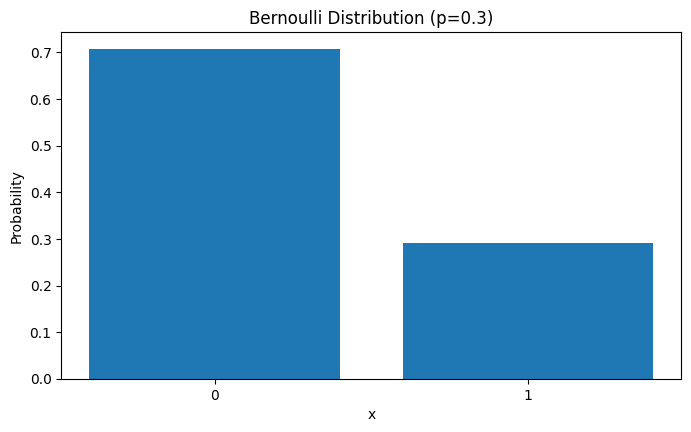

In [9]:
# 베르누이분포 시뮬레이션
bernoulli = np.random.binomial(n=1, p=0.3, size=1000)
values, counts = np.unique(bernoulli, return_counts=True)

plt.bar(values, counts / counts.sum())
plt.xticks([0, 1])
plt.title("Bernoulli Distribution (p=0.3)")
plt.xlabel("x")
plt.ylabel("Probability")
plt.show()


---

## 8-2. 이항분포

이항분포는 **베르누이 시행을 여러 번 반복했을 때 성공이 몇 번 나오는지**를 나타내는 확률분포입니다.

베르누이분포가 **한 번의 성공/실패**를 다룬다면  
이항분포는 **여러 번 시행했을 때의 성공 횟수**를 다룹니다.

예를 들면

- 동전을 10번 던졌을 때 앞면이 몇 번 나오는가
- 20개의 제품 중 불량품이 몇 개인가
- 광고를 본 100명 중 몇 명이 클릭하는가

처럼 **성공 횟수**를 모델링할 때 사용합니다.



# 1. 이항분포의 표현

성공확률이 \(p\) 인 베르누이 시행을 \(n\) 번 반복했을 때  
성공 횟수 \(X\) 는 다음과 같이 표현합니다.

$
X \sim Bin(n,p)
$

의미

- \(n\) : 시행 횟수  
- \(p\) : 각 시행의 성공 확률  
- \(X\) : 전체 성공 횟수

가능한 값은

$
X = 0,1,2,\dots,n
$

입니다.



# 2. 이항분포가 성립하는 조건

이항분포를 사용하려면 다음 조건이 필요합니다.

1️⃣ 시행을 **\(n\) 번 반복한다**  
2️⃣ 각 시행은 **성공/실패 두 결과만 가진다**  
3️⃣ **성공확률 \(p\) 가 동일하다**  
4️⃣ **각 시행은 서로 독립이다**

이 네 조건이 만족되면 성공 횟수는 이항분포를 따릅니다.



# 3. 확률질량함수 (PMF)

이항분포에서 성공이 정확히 \(x\) 번 나올 확률은

$
P(X=x)=\binom{n}{x}p^x(1-p)^{n-x}
$

입니다.

의미

- \(\binom{n}{x}\) : 성공이 \(x\) 번 나오는 **경우의 수**
- \(p^x\) : 성공 \(x\) 번이 발생할 확률
- \((1-p)^{n-x}\) : 실패 \(n-x\) 번이 발생할 확률

즉 **성공이 \(x\) 번 나오는 모든 경우를 합친 확률**입니다.


# 4. 간단한 예

공정한 동전을 3번 던질 때  
앞면이 정확히 2번 나올 확률을 구해보겠습니다.

- \(n=3\)
- \(p=0.5\)
- \(x=2\)

$
P(X=2)=\binom{3}{2}(0.5)^2(0.5)^1
$

$
=3 \times 0.25 \times 0.5 = 0.375
$

즉 앞면이 2번 나올 확률은 **0.375** 입니다.



# 5. 기댓값

이항분포의 기댓값은

$
E(X)=np
$

입니다.

의미

> 전체 시행 중 평균적으로 성공이 몇 번 발생하는지를 의미합니다.

예

- 동전 10번, \(p=0.5\) → 평균 성공 5번
- 제품 20개, 불량확률 0.1 → 평균 불량 2개



# 6. 분산

이항분포의 분산은

$
Var(X)=np(1-p)
$

입니다.

의미

> 성공 횟수가 평균 주변에서 얼마나 변동하는지를 나타냅니다.

특징

- \(n\) 이 커질수록 분산 증가
- \(p=0.5\) 근처에서 분산이 가장 큼
- \(p\) 가 0 또는 1에 가까우면 분산이 작음



# 7. 베르누이분포와의 관계

| 분포 | 의미 |
|---|---|
| 베르누이분포 | 한 번의 성공/실패 |
| 이항분포 | 여러 번 시행했을 때 성공 횟수 |

즉

> **이항분포 = 베르누이 시행을 여러 번 반복한 결과**

입니다.



# 핵심 정리

- 이항분포는 성공확률 \(p\) 인 베르누이 시행을 \(n\) 번 반복했을 때 **성공 횟수의 분포**이다.
- 확률질량함수  

$
P(X=x)=\binom{n}{x}p^x(1-p)^{n-x}
$

- 기댓값  

$
E(X)=np
$

- 분산  

$
Var(X)=np(1-p)
$


# 한 줄 요약

이항분포는 **성공/실패 실험을 여러 번 반복했을 때 성공이 총 몇 번 나오는지를 설명하는 확률분포**입니다.

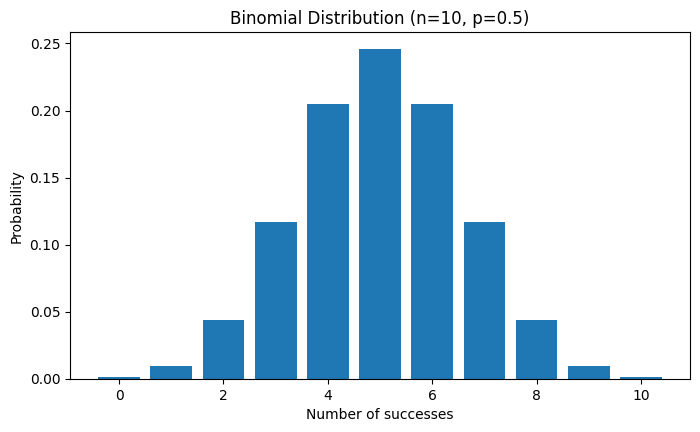

기댓값 = 5.0
분산 = 2.5


In [10]:
# 이항분포 PMF 직접 계산
n, p = 10, 0.5
xs = np.arange(0, n + 1)
pmf = np.array([comb(n, k) * (p ** k) * ((1-p) ** (n-k)) for k in xs])

plt.bar(xs, pmf)
plt.title("Binomial Distribution (n=10, p=0.5)")
plt.xlabel("Number of successes")
plt.ylabel("Probability")
plt.show()

print("기댓값 =", n * p)
print("분산 =", n * p * (1 - p))


### 8-3. 다항분포

이항분포가 성공/실패 두 범주였다면,  
`다항분포`는 `세 범주 이상인 경우`를 다룹니다.

예:
- 설문 응답: 매우만족 / 만족 / 보통 / 불만
- 주사위 눈 1~6 빈도

시험에서는 이름과 개념 정도를 알아두면 충분한 경우가 많습니다.


In [11]:
# 다항분포 예시
mult = np.random.multinomial(n=100, pvals=[0.2, 0.5, 0.3], size=1)
print("범주별 빈도 예시:", mult[0])


범주별 빈도 예시: [15 51 34]


### 8-4. 포아송분포

`단위 시간` 또는 `단위 공간`에서 사건이 몇 번 발생하는지를 나타냅니다.

$$
X \sim Poisson(\lambda)
$$

확률질량함수:

$$
P(X=x)=\frac{e^{-\lambda}\lambda^x}{x!}
$$

특징:
- 단위당 발생 횟수 모형
- 기댓값 = 분산 = $\lambda$

예:
- 1시간 동안 걸려온 전화 수
- 1분 동안 도착한 고객 수
- 문서 1페이지당 오타 수


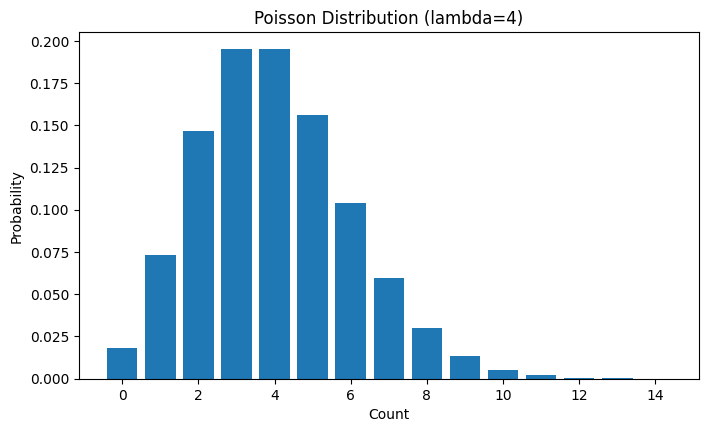

기댓값 = 4
분산 = 4


In [12]:
# 포아송분포 PMF
lam = 4
xs = np.arange(0, 15)
pmf = np.array([math.exp(-lam) * lam**k / math.factorial(k) for k in xs])

plt.bar(xs, pmf)
plt.title("Poisson Distribution (lambda=4)")
plt.xlabel("Count")
plt.ylabel("Probability")
plt.show()

print("기댓값 =", lam)
print("분산 =", lam)


### 8-5. 기하분포

`**처음 성공이 나올 때까지**` 걸리는 시행 횟수의 분포입니다.

예:
- 첫 구매가 일어날 때까지 광고를 몇 번 보여줘야 하는가
- 첫 불량품이 나올 때까지 몇 개를 검사해야 하는가

핵심 키워드:
- 처음 성공까지
- 기억없음 성질


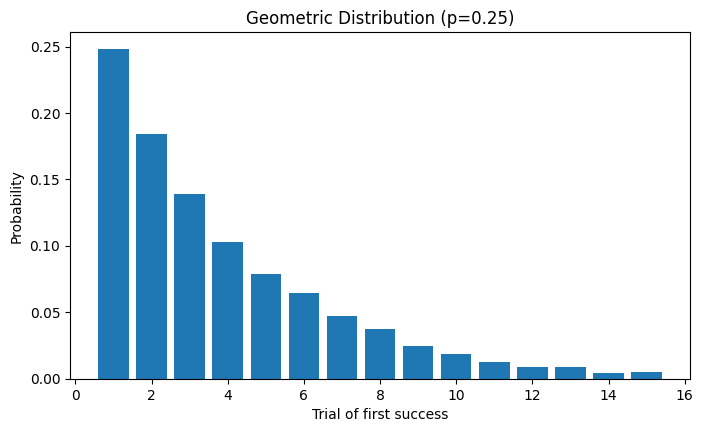

In [13]:
# 기하분포 시뮬레이션
geom = np.random.geometric(p=0.25, size=5000)
vals, counts = np.unique(geom, return_counts=True)

plt.bar(vals[:15], (counts / counts.sum())[:15])
plt.title("Geometric Distribution (p=0.25)")
plt.xlabel("Trial of first success")
plt.ylabel("Probability")
plt.show()


### 8-6. 초기하분포

복원추출이 아닌 경우의 성공 개수 분포입니다.

예:
- 불량품 10개가 섞인 100개 제품 중 5개를 `**비복원 추출**`할 때 불량품 개수

비교:

- 이항분포: 복원추출, 독립
- 초기하분포: 비복원추출, 독립 아님


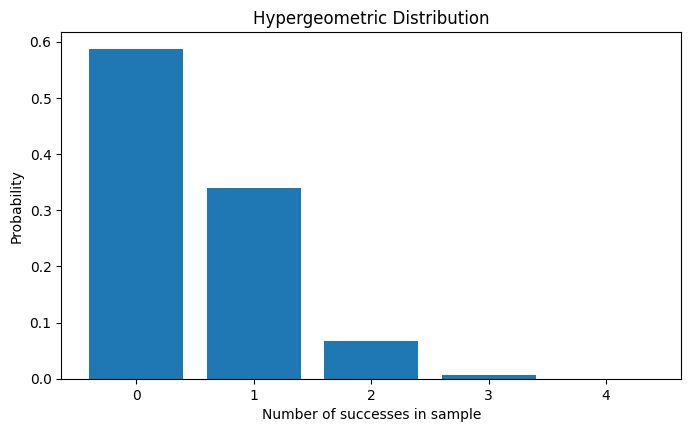

In [14]:
# 초기하분포 시뮬레이션 예시
# 전체 100개 중 성공 10개, 실패 90개, 5개 비복원 추출
N, K, n_draw = 100, 10, 5
hyper = np.random.hypergeometric(ngood=K, nbad=N-K, nsample=n_draw, size=10000)

vals, counts = np.unique(hyper, return_counts=True)
plt.bar(vals, counts / counts.sum())
plt.title("Hypergeometric Distribution")
plt.xlabel("Number of successes in sample")
plt.ylabel("Probability")
plt.show()


## 9. 연속확률분포

연속형에서는 특정 한 점의 확률보다 **구간의 확률**을 다루는 것이 중요합니다.


### 9-1. 균등분포 (Uniform Distribution)


균등분포는 `**일정한 구간 안의 모든 값이 동일한 밀도를 가지는 연속확률분포**`입니다.

즉 구간 \([a,b]\) 안에서는 어느 값도 특별히 더 자주 나오지 않습니다.

표현

$$
X \sim U(a,b)
$$

확률밀도함수

$$
f(x)=\frac{1}{b-a}, \quad a \le x \le b
$$

기댓값

$$
E(X)=\frac{a+b}{2}
$$

분산

$$
Var(X)=\frac{(b-a)^2}{12}
$$

### 핵심

- 구간 안의 **모든 값의 밀도가 동일**
- 확률은 **구간 길이 비율로 계산**
## 한 줄 요약

균등분포는 **일정한 구간 안에서 모든 값이 고르게 나타난다고 보는 가장 기본적인 연속확률분포**입니다.

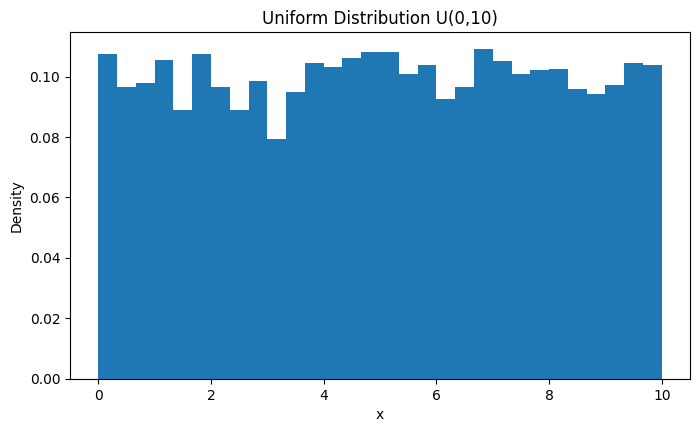

In [15]:
# 균등분포 시뮬레이션
uniform = np.random.uniform(0, 10, size=5000)

plt.hist(uniform, bins=30, density=True)
plt.title("Uniform Distribution U(0,10)")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()


---

### 9-2. 지수분포

사건이 발생할 때까지의 `**대기시간**`을 나타내는 분포입니다.

$$
X \sim Exp(\lambda)
$$

기댓값과 분산:

$$
E(X)=\frac{1}{\lambda}
$$

$$
Var(X)=\frac{1}{\lambda^2}
$$

예:
- 고객이 다음에 도착할 때까지의 시간
- 장비가 다음에 고장날 때까지의 시간

핵심 특징:
- 기억없음 성질


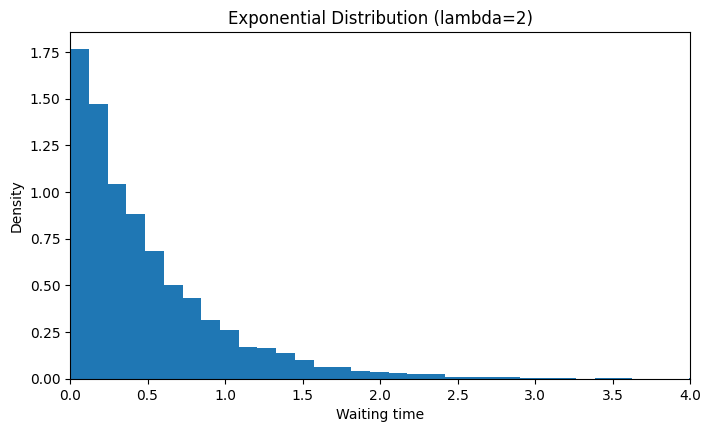

In [16]:
# 지수분포 시뮬레이션
expo = np.random.exponential(scale=1/2, size=5000)  # lambda=2

plt.hist(expo, bins=40, density=True)
plt.title("Exponential Distribution (lambda=2)")
plt.xlabel("Waiting time")
plt.ylabel("Density")
plt.xlim(0, 4)
plt.show()


### 9-3. 정규분포

가장 중요한 연속확률분포입니다.

$$
X \sim N(\mu, \sigma^2)
$$

특징:
- 종 모양
- 좌우 대칭
- 평균 = 중앙값 = 최빈값
- 자연 현상과 오차에서 자주 등장

### 표준정규분포와 Z-점수

$$
Z=\frac{X-\mu}{\sigma}
$$

이렇게 하면 평균 0, 표준편차 1인 표준정규분포로 바뀝니다.


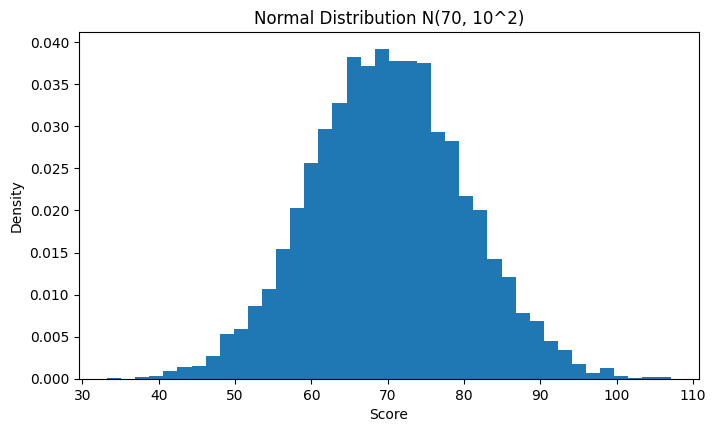

점수 85의 Z-점수 = 1.5


In [17]:
# 정규분포 시뮬레이션
normal = np.random.normal(loc=70, scale=10, size=5000)

plt.hist(normal, bins=40, density=True)
plt.title("Normal Distribution N(70, 10^2)")
plt.xlabel("Score")
plt.ylabel("Density")
plt.show()

x = 85
z = (x - 70) / 10
print("점수 85의 Z-점수 =", z)


### 9-4. 감마분포

지수분포의 확장으로 생각하면 이해가 쉽습니다.  
여러 번의 사건이 발생할 때까지 걸리는 총시간 등을 다루는 데 쓰입니다.

시험에서는 보통

- 지수분포와의 관계
- 대기시간 계열 분포

정도로 이해하면 좋습니다.


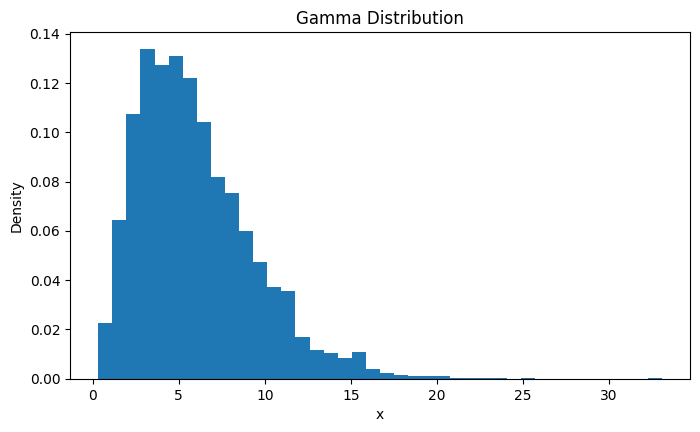

In [18]:
# 감마분포 시뮬레이션
gamma = np.random.gamma(shape=3, scale=2, size=5000)

plt.hist(gamma, bins=40, density=True)
plt.title("Gamma Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()


### 9-5. 카이제곱분포

`표준정규분포를 따르는 변수들의 제곱합`으로 만들어지는 분포입니다.

활용:
- `적합도 검정`
- `독립성 검정`
- 분산 관련 문제

특징:
- 0 이상
- 자유도에 따라 모양이 달라짐


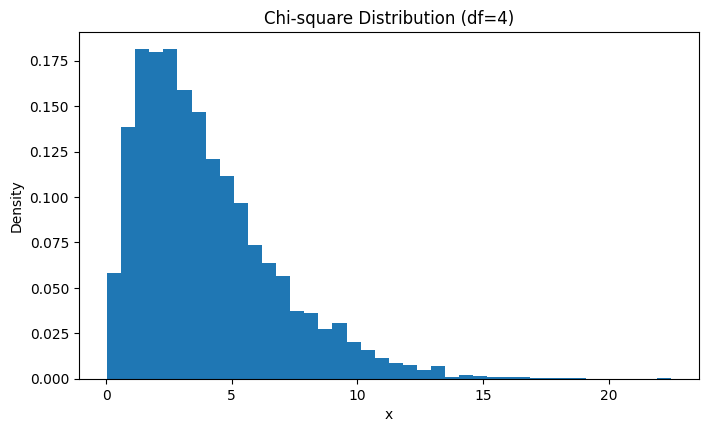

In [19]:
# 카이제곱분포 시뮬레이션
chi2 = np.random.chisquare(df=4, size=5000)

plt.hist(chi2, bins=40, density=True)
plt.title("Chi-square Distribution (df=4)")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()


### 9-6. t분포

`모집단 분산을 모르고, 표본 크기가 작을 때` 평균 추론에 많이 사용합니다.

특징:
- 정규분포와 비슷하지만 `꼬리가 더 두꺼움`
- 자유도가 커질수록 정규분포에 가까워짐

핵심 문장:

> 모분산 미지 + 소표본 -> t분포


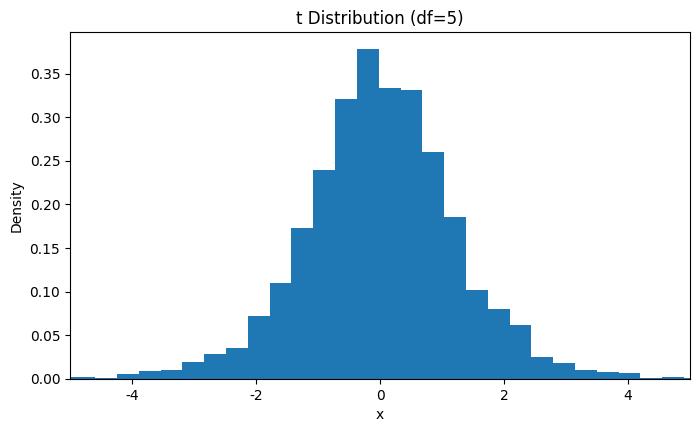

In [20]:
# t분포 시뮬레이션
tvals = np.random.standard_t(df=5, size=5000)

plt.hist(tvals, bins=60, density=True)
plt.title("t Distribution (df=5)")
plt.xlabel("x")
plt.ylabel("Density")
plt.xlim(-5, 5)
plt.show()


### 9-7. F분포

`두 분산의 비율`과 관련된 분포입니다.

활용:
- `분산분석(ANOVA)`
- 회귀모형 전체 유의성 검정

핵심:
- 항상 0 이상
- `자유도 2개`가 필요


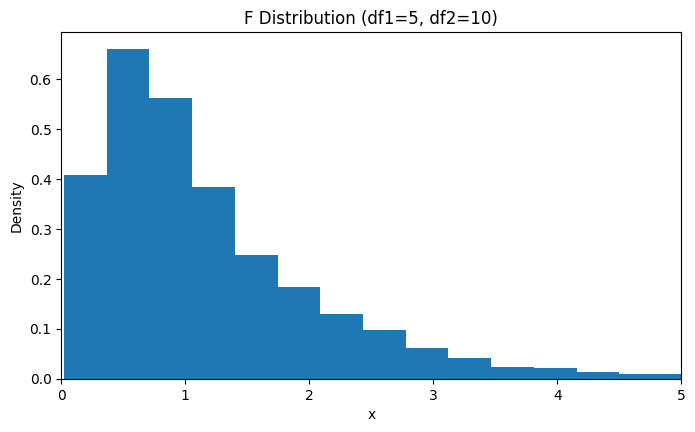

In [21]:
# F분포 시뮬레이션
fvals = np.random.f(dfnum=5, dfden=10, size=5000)

plt.hist(fvals, bins=60, density=True)
plt.title("F Distribution (df1=5, df2=10)")
plt.xlabel("x")
plt.ylabel("Density")
plt.xlim(0, 5)
plt.show()


## 10. 표본분포와 중심극한정리

이 파트는 통계추론의 핵심입니다.

### 10-1. 표본분포란?

표본을 한 번 뽑아서 얻은 값이 아니라,  
**표본을 여러 번 반복해서 뽑았을 때 통계량이 어떻게 분포하는지**를 보는 것입니다.

예:
- 표본평균의 분포
- 표본비율의 분포

### 10-2. 표본평균의 기대값과 분산

표본평균 $\bar{X}$ 에 대해

$$
E(\bar{X})=\mu
$$

즉, 표본평균은 모집단 평균의 좋은 추정량입니다.

또한

$$
Var(\bar{X})=\frac{\sigma^2}{n}
$$

표준편차는

$$
\frac{\sigma}{\sqrt{n}}
$$

이고, 이것을 **표준오차(Standard Error)** 라고 부릅니다.

### 10-3. 중심극한정리

모집단 분포가 정규분포가 아니어도,

- 표본 크기 $n$ 이 충분히 크면
- 표본평균의 분포는 정규분포에 가까워집니다.

즉,

$$
\bar{X} \approx N\left(\mu, \frac{\sigma^2}{n}\right)
$$

이 성질 덕분에 신뢰구간, 가설검정이 가능해집니다.


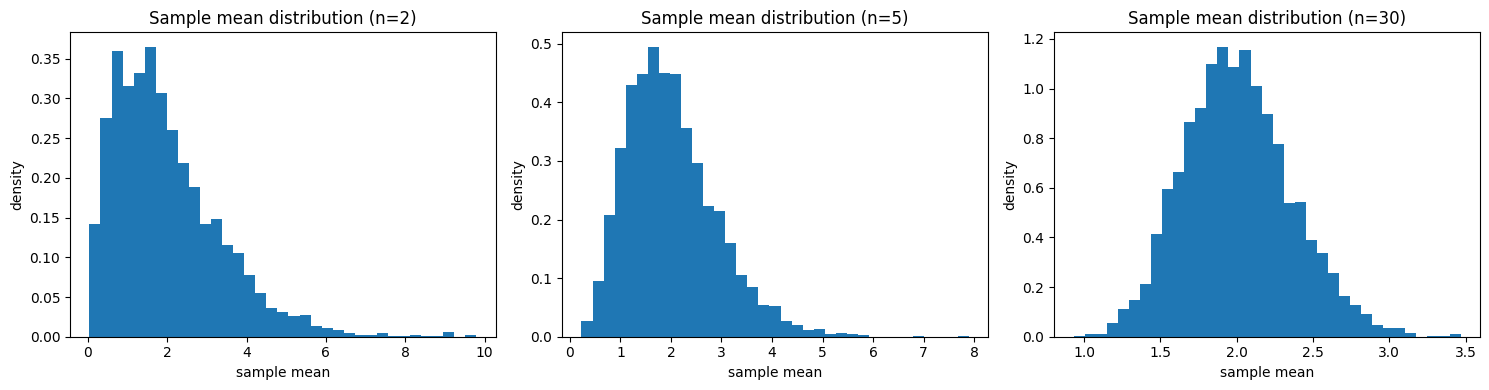

In [22]:
# 중심극한정리 시뮬레이션
# 모집단은 오른쪽으로 치우친 지수분포
population = np.random.exponential(scale=2, size=200000)

sample_sizes = [2, 5, 30]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n in zip(axes, sample_sizes):
    means = []
    for _ in range(3000):
        sample = np.random.choice(population, size=n, replace=True)
        means.append(sample.mean())
    ax.hist(means, bins=35, density=True)
    ax.set_title(f"Sample mean distribution (n={n})")
    ax.set_xlabel("sample mean")
    ax.set_ylabel("density")

plt.tight_layout()
plt.show()


### 해설

표본 크기가 커질수록 표본평균의 분포가 점점 더 **정규분포처럼 매끈해지는 것**을 볼 수 있습니다.  
이것이 중심극한정리입니다.


## 11. 표준편차와 표준오차

학생들이 가장 자주 헷갈리는 개념입니다.

### 11-1. 표준편차(Standard Deviation)

데이터 하나하나가 평균에서 얼마나 퍼져 있는지를 나타냅니다.

### 11-2. 표준오차(Standard Error)

표본평균이 모집단평균 주변에서 얼마나 흔들리는지를 나타냅니다.

$$
SE = \frac{\sigma}{\sqrt{n}}
$$

### 비교

- 표준편차: **데이터의 퍼짐**
- 표준오차: **표본평균의 퍼짐**

표본 크기 $n$ 이 커지면:

- 표준편차는 크게 변하지 않을 수 있음
- 표준오차는 작아짐


In [23]:
# 표준편차와 표준오차 비교
population = np.random.normal(50, 12, size=100000)

sample_sizes = [10, 30, 100, 500]
rows = []

for n in sample_sizes:
    sample = np.random.choice(population, size=n, replace=False)
    sd = sample.std(ddof=1)
    se = sd / np.sqrt(n)
    rows.append([n, sd, se])

result = pd.DataFrame(rows, columns=["n", "sample_sd", "standard_error"])
result


,n,sample_sd,standard_error
0,10,10.422521,3.295891
1,30,13.857127,2.529954
2,100,10.556721,1.055672
3,500,11.742788,0.525153


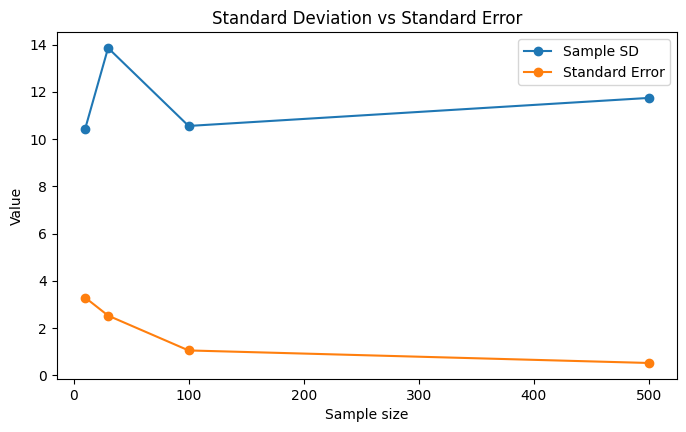

In [24]:
plt.plot(result["n"], result["sample_sd"], marker="o", label="Sample SD")
plt.plot(result["n"], result["standard_error"], marker="o", label="Standard Error")
plt.title("Standard Deviation vs Standard Error")
plt.xlabel("Sample size")
plt.ylabel("Value")
plt.legend()
plt.show()


## 12. 표본비율의 분포

어떤 사건의 성공/실패처럼 이진형 자료에서는 **표본비율**이 중요합니다.

표본비율을 $\hat{p}$ 라고 하면

$$
\hat{p} = \frac{X}{n}
$$

기댓값:

$$
E(\hat{p})=p
$$

표준오차:

$$
SE(\hat{p})=\sqrt{\frac{p(1-p)}{n}}
$$

표본 수가 충분히 크면 표본비율도 정규분포로 근사할 수 있습니다.


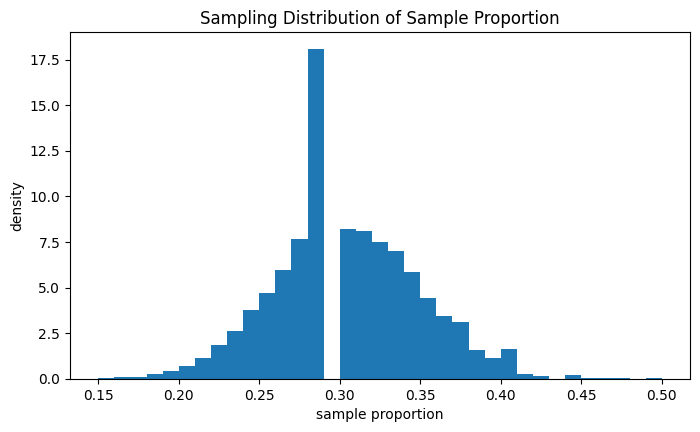

시뮬레이션 평균: 0.3002
이론적 표준오차: 0.0458
시뮬레이션 표준편차: 0.0454


In [25]:
# 표본비율 분포 시뮬레이션
p = 0.3
n = 100

props = []
for _ in range(5000):
    sample = np.random.binomial(1, p, size=n)
    props.append(sample.mean())

plt.hist(props, bins=35, density=True)
plt.title("Sampling Distribution of Sample Proportion")
plt.xlabel("sample proportion")
plt.ylabel("density")
plt.show()

print("시뮬레이션 평균:", round(np.mean(props), 4))
print("이론적 표준오차:", round(np.sqrt(p*(1-p)/n), 4))
print("시뮬레이션 표준편차:", round(np.std(props, ddof=1), 4))


## 13. 시험에서 자주 헷갈리는 개념 비교표


In [26]:
compare = pd.DataFrame({
    "개념1": ["모집단", "모수", "표준편차", "층화추출", "이항분포", "포아송분포", "정규분포", "독립"],
    "개념2": ["표본", "통계량", "표준오차", "군집추출", "초기하분포", "지수분포", "t분포", "배반"],
    "핵심 차이": [
        "전체 vs 일부",
        "모집단 값 vs 표본으로 계산한 값",
        "데이터의 퍼짐 vs 표본평균의 퍼짐",
        "모든 층에서 일부 추출 vs 군집 몇 개를 통째로 선택",
        "복원추출/독립 vs 비복원추출/비독립",
        "발생 횟수 vs 대기시간",
        "모분산 알 때/큰 표본에 익숙 vs 모분산 미지/소표본",
        "영향 없음 vs 동시에 일어날 수 없음"
    ]
})
compare


,개념1,개념2,핵심 차이
0,모집단,표본,전체 vs 일부
1,모수,통계량,모집단 값 vs 표본으로 계산한 값
2,표준편차,표준오차,데이터의 퍼짐 vs 표본평균의 퍼짐
3,층화추출,군집추출,모든 층에서 일부 추출 vs 군집 몇 개를 통째로 선택
4,이항분포,초기하분포,복원추출/독립 vs 비복원추출/비독립
5,포아송분포,지수분포,발생 횟수 vs 대기시간
6,정규분포,t분포,모분산 알 때/큰 표본에 익숙 vs 모분산 미지/소표본
7,독립,배반,영향 없음 vs 동시에 일어날 수 없음


## 14. 계산형 예제 문제

### 문제 1. 조건부확률

전체 고객 500명 중 멤버십 가입자는 200명이고,  
멤버십 가입자 중 구매자는 50명이다.  
멤버십 가입 고객의 구매 확률은?

### 풀이

$$
P(구매|멤버십)=\frac{50}{200}=0.25
$$

즉 25%


In [27]:
# 문제 1 계산
50 / 200


0.25

### 문제 2. 이항분포의 기댓값과 분산

성공확률이 0.2인 사건을 20번 반복한다.  
성공 횟수의 기댓값과 분산은?

### 풀이

$$
E(X)=np=20\times0.2=4
$$

$$
Var(X)=np(1-p)=20\times0.2\times0.8=3.2
$$


In [28]:
n, p = 20, 0.2
print("기댓값:", n * p)
print("분산:", n * p * (1 - p))


기댓값: 4.0
분산: 3.2


### 문제 3. 표준오차

모집단 표준편차가 12이고, 표본 크기가 36일 때 표본평균의 표준오차는?

### 풀이

$$
SE=\frac{12}{\sqrt{36}}=2
$$


In [29]:
12 / np.sqrt(36)


np.float64(2.0)

### 문제 4. 베이즈 정리

- 질병 유병률: 1%
- 질병이 있으면 양성: 95%
- 질병이 없는데 양성: 5%

양성 판정을 받은 사람이 실제 질병일 확률은?

### 풀이

$$
P(D|+)=\frac{0.95\times0.01}{0.95\times0.01 + 0.05\times0.99}
\approx 0.161
$$

즉 약 16.1%


In [30]:
num = 0.95 * 0.01
den = 0.95 * 0.01 + 0.05 * 0.99
num / den


0.16101694915254236

## 15. 최종 암기 포인트

### 반드시 외워야 하는 공식

#### 조건부확률
$$
P(A|B)=\frac{P(A\cap B)}{P(B)}
$$

#### 합집합
$$
P(A\cup B)=P(A)+P(B)-P(A\cap B)
$$

#### 독립
$$
P(A\cap B)=P(A)P(B)
$$

#### 베이즈 정리
$$
P(A|B)=\frac{P(B|A)P(A)}{P(B)}
$$

#### 이항분포
$$
E(X)=np, \quad Var(X)=np(1-p)
$$

#### 포아송분포
$$
E(X)=Var(X)=\lambda
$$

#### 표본평균의 표준오차
$$
SE(\bar{X})=\frac{\sigma}{\sqrt{n}}
$$

#### 표본비율의 표준오차
$$
SE(\hat{p})=\sqrt{\frac{p(1-p)}{n}}
$$

### 반드시 구분해야 하는 개념

- 모집단 vs 표본
- 모수 vs 통계량
- 표준편차 vs 표준오차
- 층화추출 vs 군집추출
- 독립 vs 배반
- 이항분포 vs 초기하분포
- 포아송분포 vs 지수분포
- 정규분포 vs t분포


## 16. 한 줄 요약

이 PDF 범위의 핵심은 다음 한 문장으로 정리할 수 있습니다.

> **표본을 통해 모집단을 이해하기 위해, 확률과 분포와 표본분포를 배우는 것**이 통계의 핵심입니다.

이 노트북을 충분히 이해하면 빅데이터분석기사 통계 파트의 큰 뼈대를 잡을 수 있습니다.
